In [1]:
#vmax_r240703_ECA.csv

In [2]:
import os,glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr # to read .rds files

In [3]:
path_in = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/"


In [70]:

fnames={}

case_id = "FACE_1PFT_AllomBl_r240326_AgBgW_daily"
case_id = "FACE_1PFT_r240701_dL2FR_p0.2" # density 0.2 #/m2

case_ids = [#"FACE_1PFT_r240701_dL2FR_p0.2", # density 0.2 #/m2
            "FACE_1PFT_r240704_dL2FR",       # respective densities
            "FACE_1PFT_r240711a_dL2FR" 
           ]

sites= ("US-ORN", "US-DUK")
#sites= ("US-ORN",)#, "US-DUK")
sites= ("US-DUK" , )
#run_cases = ["aCO2", "eCO2"]
run_cases = ["trans", ]
#run_case = "spins"
run_case = "trans"
#run_case = "aCO2"
#run_case = "eCO2"


for case_id in case_ids:
    for site in sites:
        for run_case in run_cases:
            # COnly
            #fnames[f"{case_id}_{site}_COnly_{run_case}"] = f"{path_in}{case_id}_processed/{case_id}_{site}_{run_case}.nc"
            # RD
            fn = ['RD','ECA']
            for f in fn:
                fnames[f"{case_id}_{site}_{f}_{run_case}"] = f"{path_in}{case_id}_{f}_processed/{case_id}_{f}_{site}_{run_case}.nc"


In [71]:
 fnames

{'FACE_1PFT_r240704_dL2FR_US-DUK_RD_trans': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r240704_dL2FR_RD_processed/FACE_1PFT_r240704_dL2FR_RD_US-DUK_trans.nc',
 'FACE_1PFT_r240704_dL2FR_US-DUK_ECA_trans': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r240704_dL2FR_ECA_processed/FACE_1PFT_r240704_dL2FR_ECA_US-DUK_trans.nc',
 'FACE_1PFT_r240711a_dL2FR_US-DUK_RD_trans': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r240711a_dL2FR_RD_processed/FACE_1PFT_r240711a_dL2FR_RD_US-DUK_trans.nc',
 'FACE_1PFT_r240711a_dL2FR_US-DUK_ECA_trans': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r240711a_dL2FR_ECA_processed/FACE_1PFT_r240711a_dL2FR_ECA_US-DUK_trans.nc'}

In [72]:
ds = {}
for idx, key in enumerate(fnames.keys()):
    print (key)
    #ds[key] = xr.open_mfdataset(fnames[key],decode_times=True)
    ds[key] = xr.open_mfdataset(fnames[key])
    ds[key] = xr.open_mfdataset(fnames[key], decode_times=False) # inorder to read the "FATES_DAYSINCE_COLDLEAFOFF". because days are interpreted differeny by xarry
    
    
#for idx, key in enumerate(ds.keys()):
#    ds[key]['time'] =  pd.to_datetime(ds[key].time.values.astype(str))

FACE_1PFT_r240704_dL2FR_US-DUK_RD_trans
FACE_1PFT_r240704_dL2FR_US-DUK_ECA_trans
FACE_1PFT_r240711a_dL2FR_US-DUK_RD_trans
FACE_1PFT_r240711a_dL2FR_US-DUK_ECA_trans


In [74]:
# How long do you want the simulation plots?
max_r_years = 150
if run_case == "spins":
    output_freq = "yearly" # spins
    multiply_factor = 1 # 365 for daily output; else 1 for yearly
else:
    output_freq = "daily" # spins
    multiply_factor = 365
    if "CO2" in run_case:
        max_r_years = 12+5

In [75]:
"-".join(key.split("_")[6:])

'trans'

In [76]:
sim_case = "COnly"
#sim_case = "RD"
#sim_case = "ECA"
sim_cases = [
            "RD",
            #"ECA",
            #"COnly",
]
#sim_cases = ["COnly",]

In [77]:
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        print (key)

FACE_1PFT_r240704_dL2FR_US-DUK_RD_trans
FACE_1PFT_r240711a_dL2FR_US-DUK_RD_trans


In [78]:
key.split('_')[2]

'r240711a'

In [79]:
def tmp_legend_name (key):
    if 'p0.2' in key:
        lname1 = "density0.2"
    else:
        if "ORN" in key:
            lname1 = "density0.36_ORN"
        elif "DUK" in key:
            lname1 = "density0.17_DUK"
    return f"{lname1}_{key.split('_')[-2]}_{key.split('_')[-1]}({key.split('_')[2]})"
    
markers_list = [".", "<", "o","^",".", "<", "o","^"]
colors_list = ["red", "green", "blue", "yellow","red", "green", "blue", "yellow"] 

In [80]:
tmp_legend_name(key)

'density0.17_DUK_ECA_trans(r240711a)'

net primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second


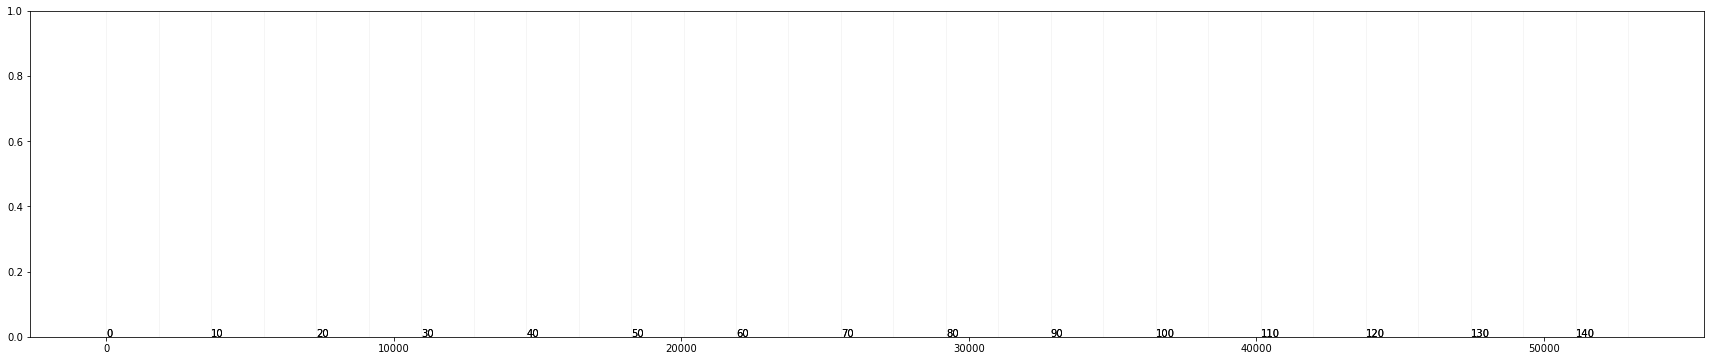

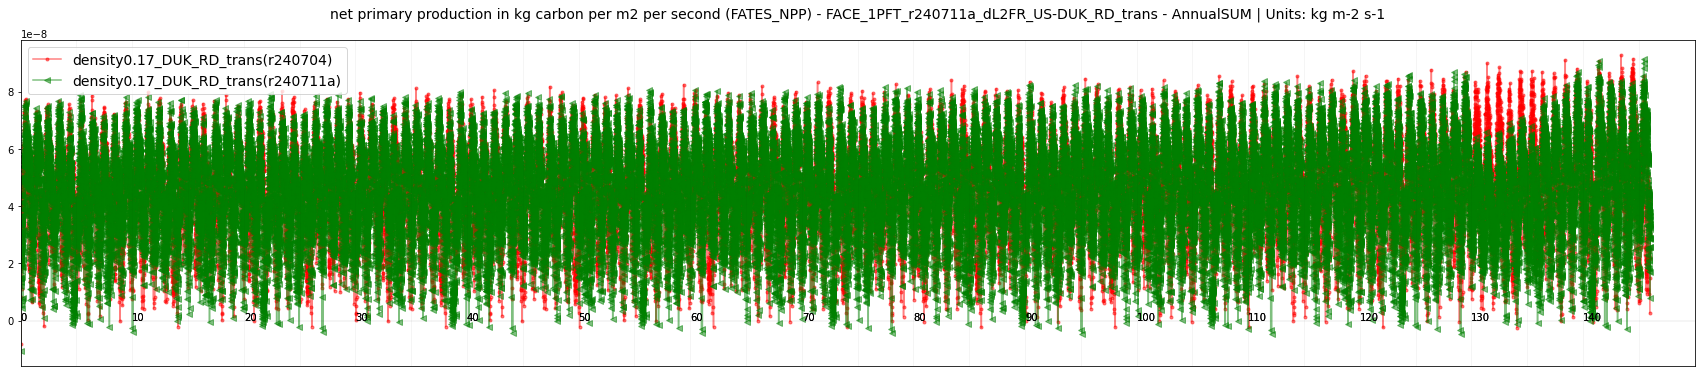

In [81]:
vars = (#"FATES_GPP",
        "FATES_NPP",
        #"FATES_AUTORESP",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

atmospheric air temperature
atmospheric air temperature


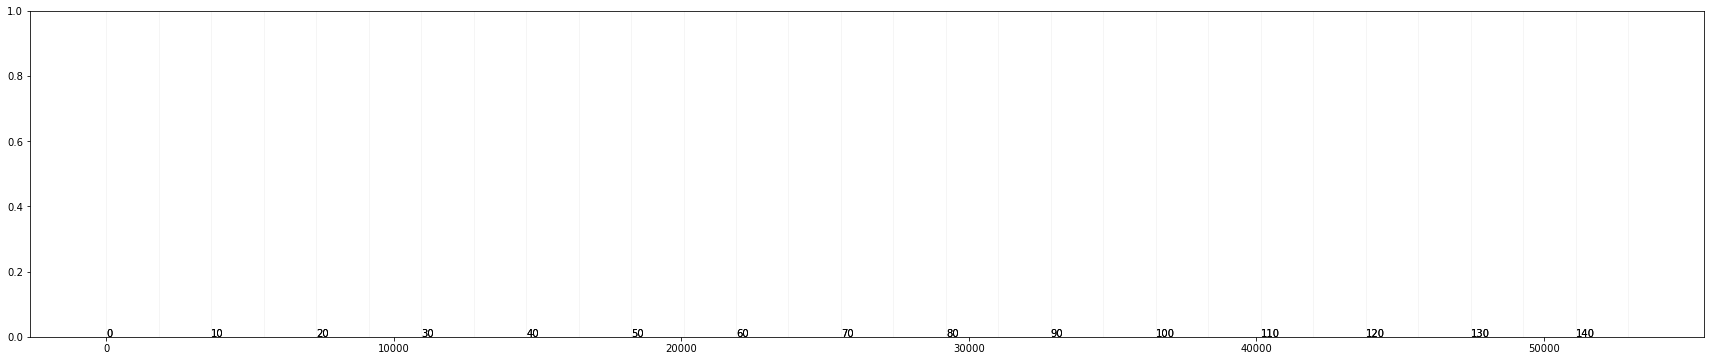

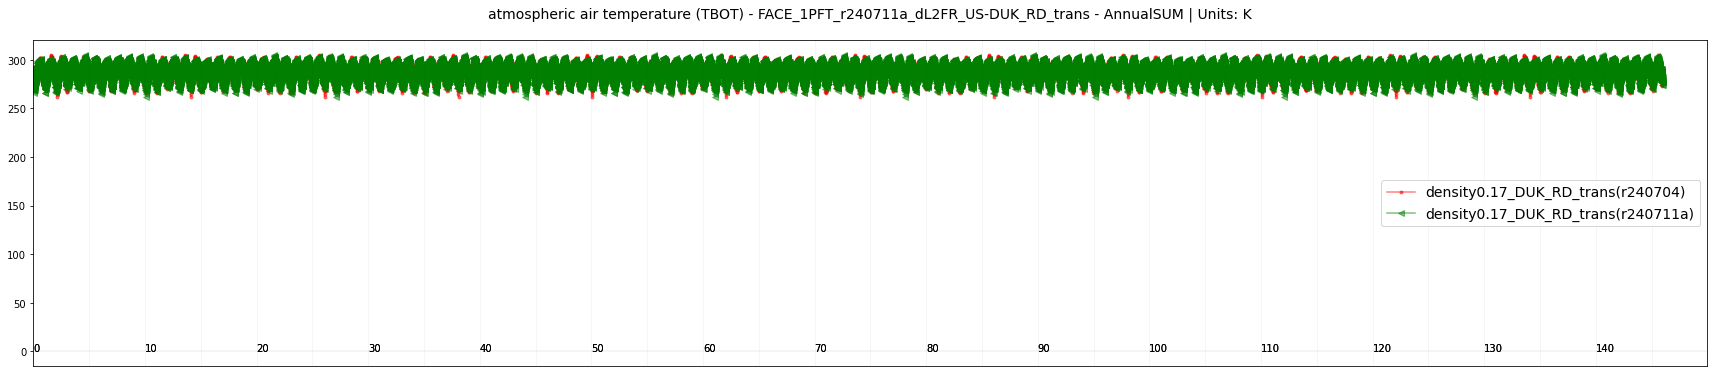

In [82]:
vars = (#"FATES_GPP",
        "TBOT",
        #"FATES_AUTORESP",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))


respiration of un-allocatable carbon gain
respiration of un-allocatable carbon gain


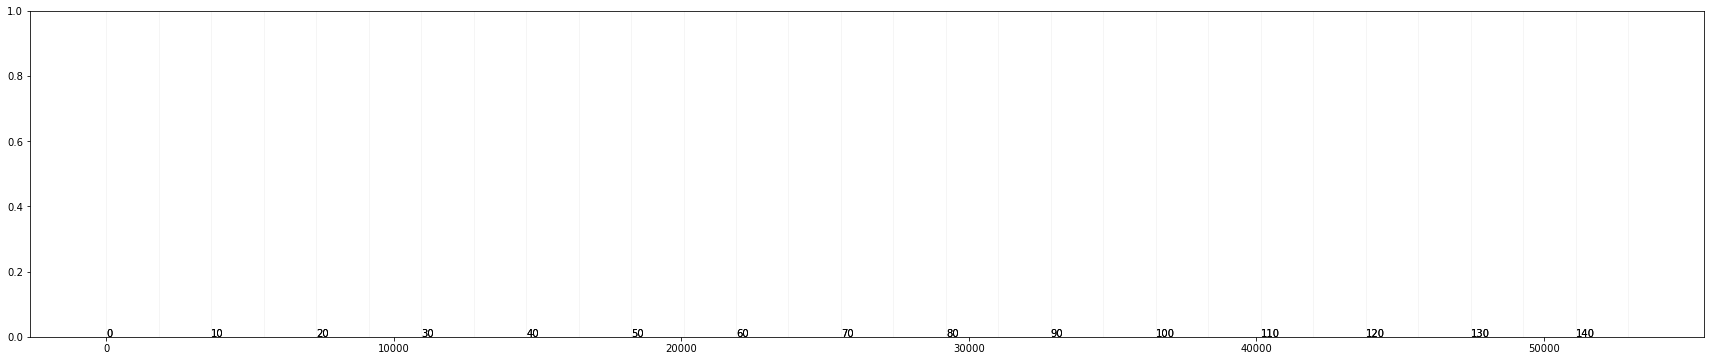

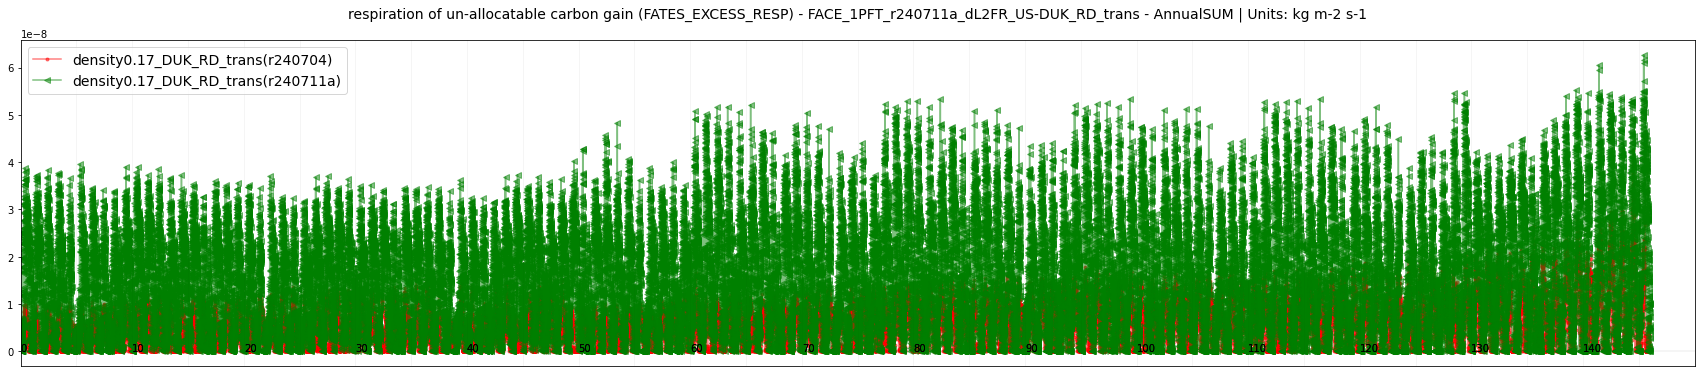

In [83]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_EXCESS_RESP",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

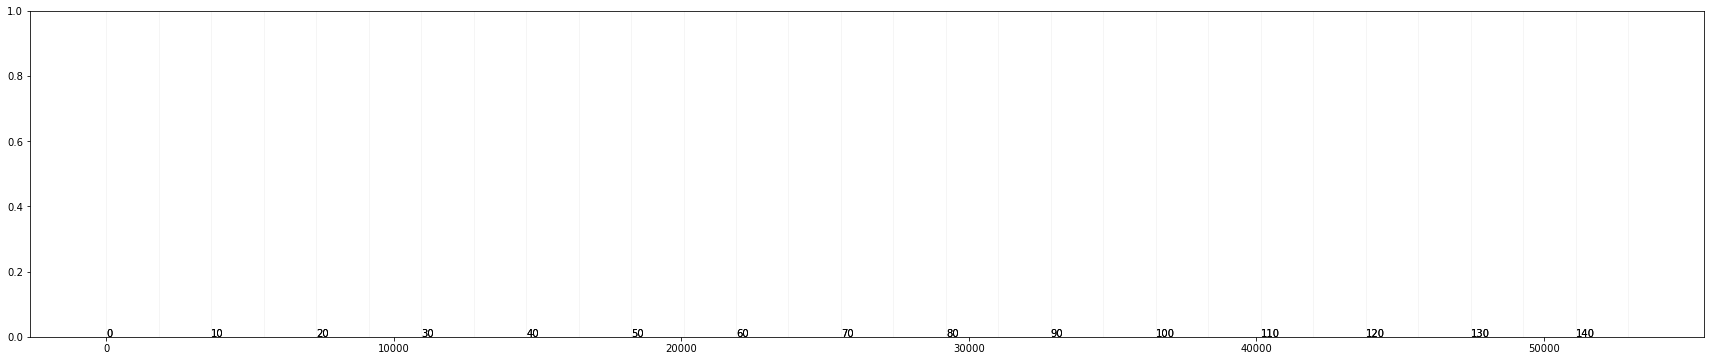

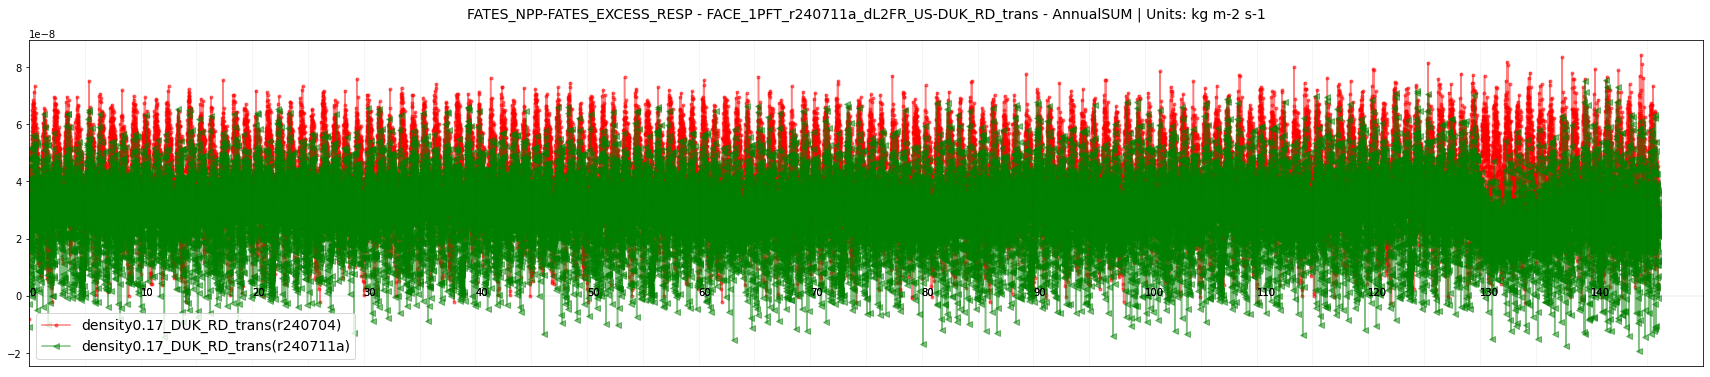

In [84]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NPP-FATES_EXCESS_RESP",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                if var =="FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var = ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]]
                    plt.plot(tmp_var, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                else:
                    plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                    print (ds[key][var].long_name )
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                if var =="FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var = ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]]
                    plt.plot(tmp_var, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                else:
                    plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                    print (ds[key][var].long_name )
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

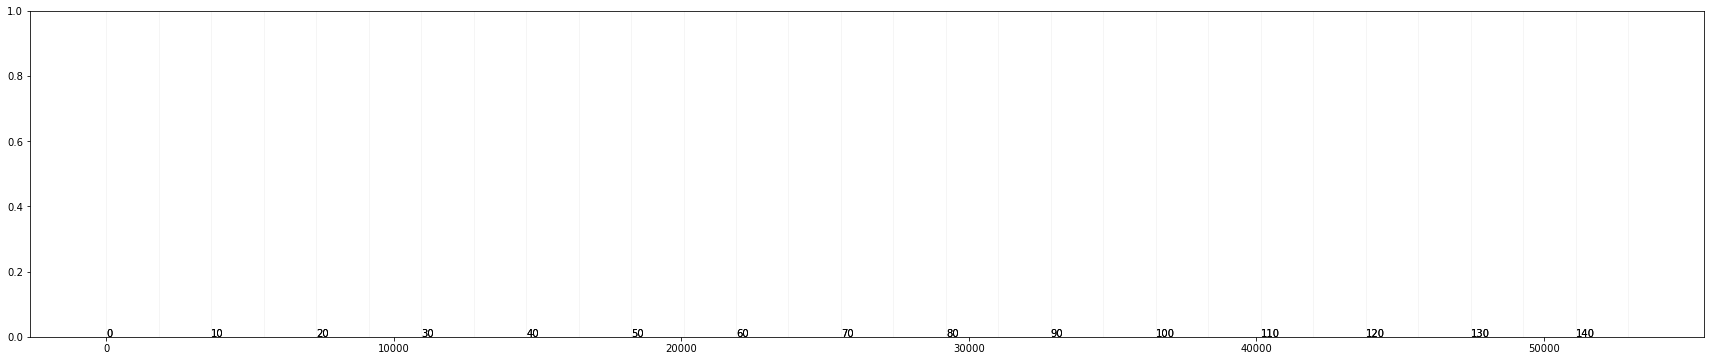

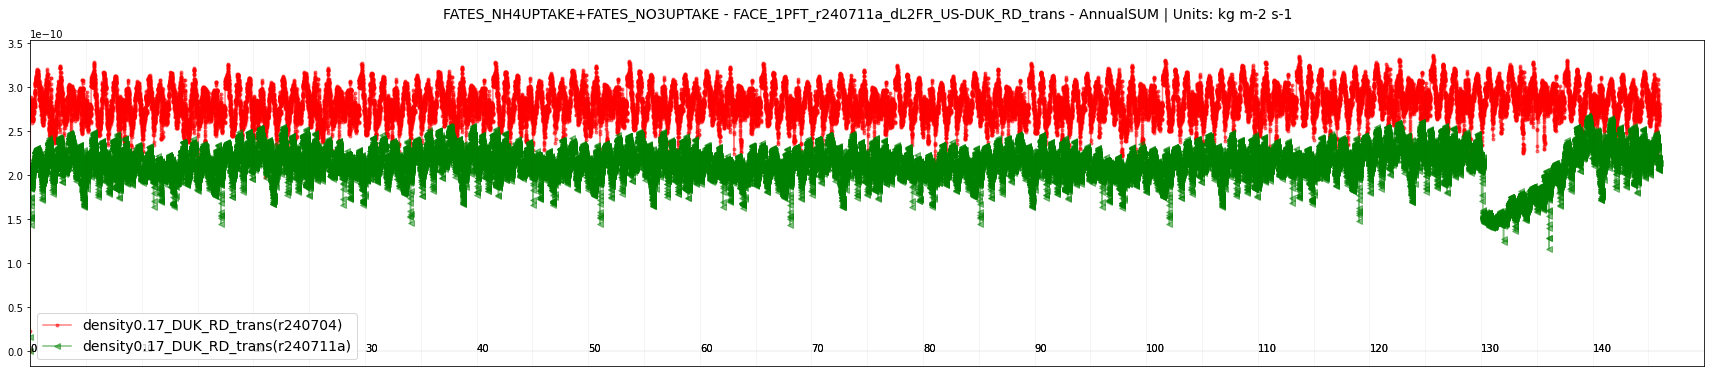

In [85]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NH4UPTAKE+FATES_NO3UPTAKE",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                if var =="FATES_NH4UPTAKE+FATES_NO3UPTAKE":
                    tmp_var = ds[key][var.split('+')[0]] + ds[key][var.split('+')[1]]
                    plt.plot(tmp_var, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('+')[0]].units}\n",fontsize=14)
                else:
                    plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                    print (ds[key][var].long_name )
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                if var =="FATES_NH4UPTAKE+FATES_NO3UPTAKE":
                    tmp_var = ds[key][var.split('+')[0]] + ds[key][var.split('+')[1]]
                    plt.plot(tmp_var, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('+')[0]].units}\n",fontsize=14)
                else:
                    plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                    plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                    print (ds[key][var].long_name )
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

The leaf to fineroot biomass multiplier for target allometry
The leaf to fineroot biomass multiplier for target allometry


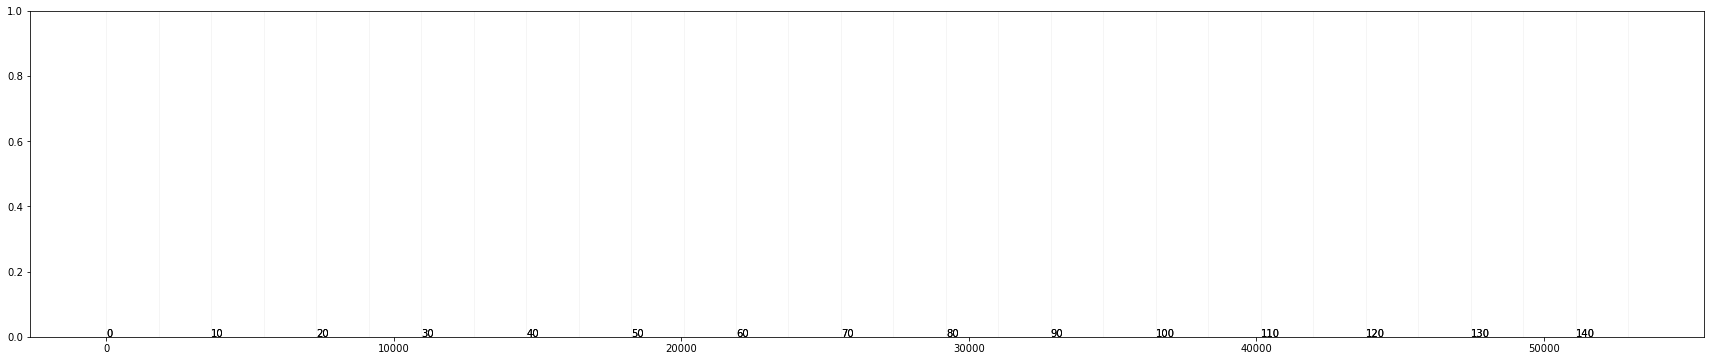

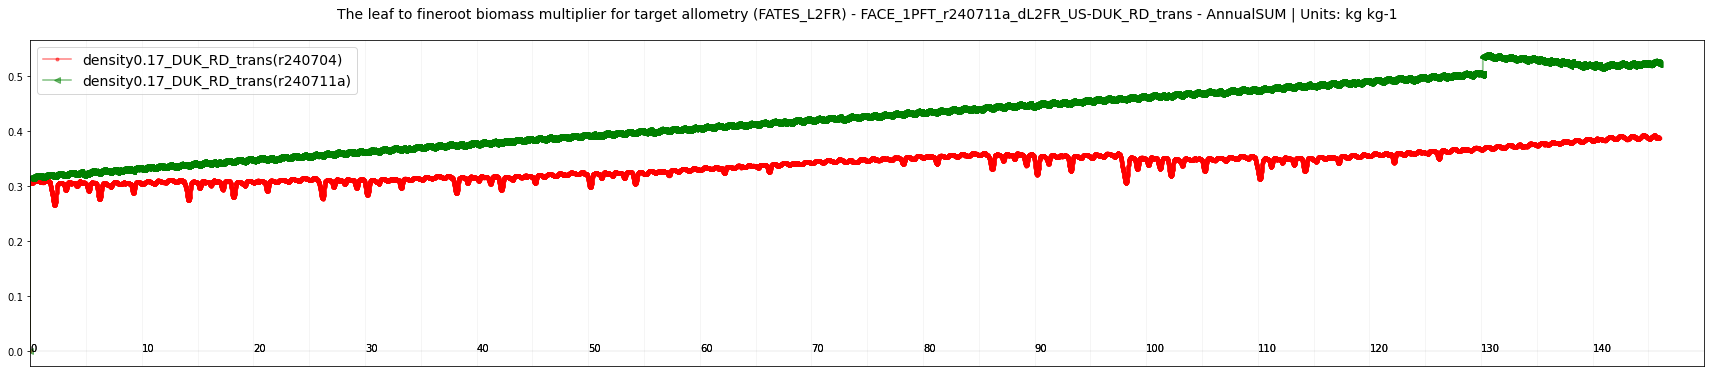

In [86]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_L2FR",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

total biomass in live plant fine roots in kg carbon per m2
total biomass in live plant fine roots in kg carbon per m2


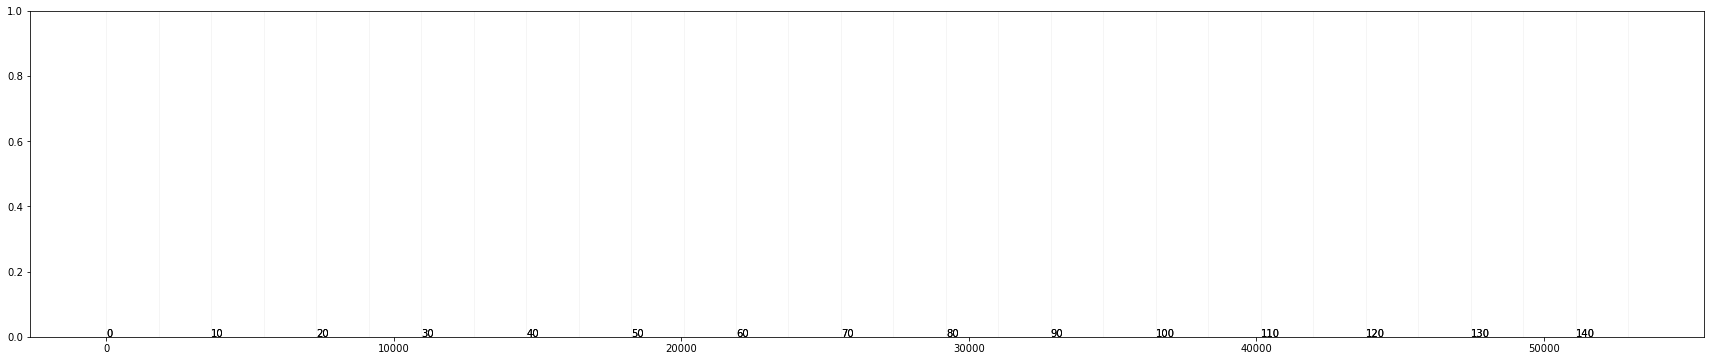

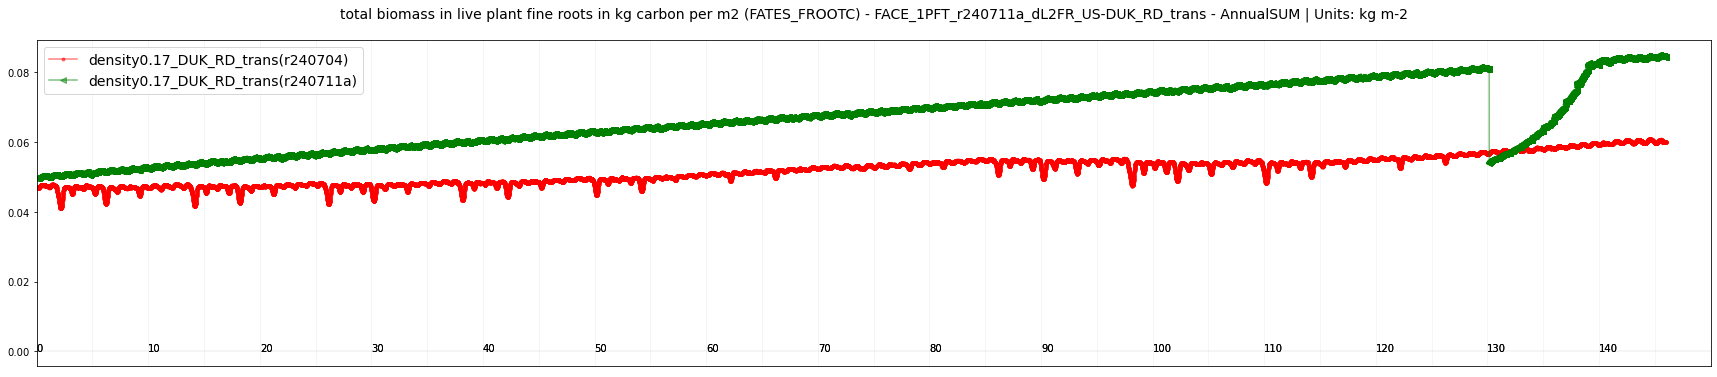

In [87]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_FROOTC",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

total biomass in live plant leaves in kg carbon per m2
total biomass in live plant leaves in kg carbon per m2


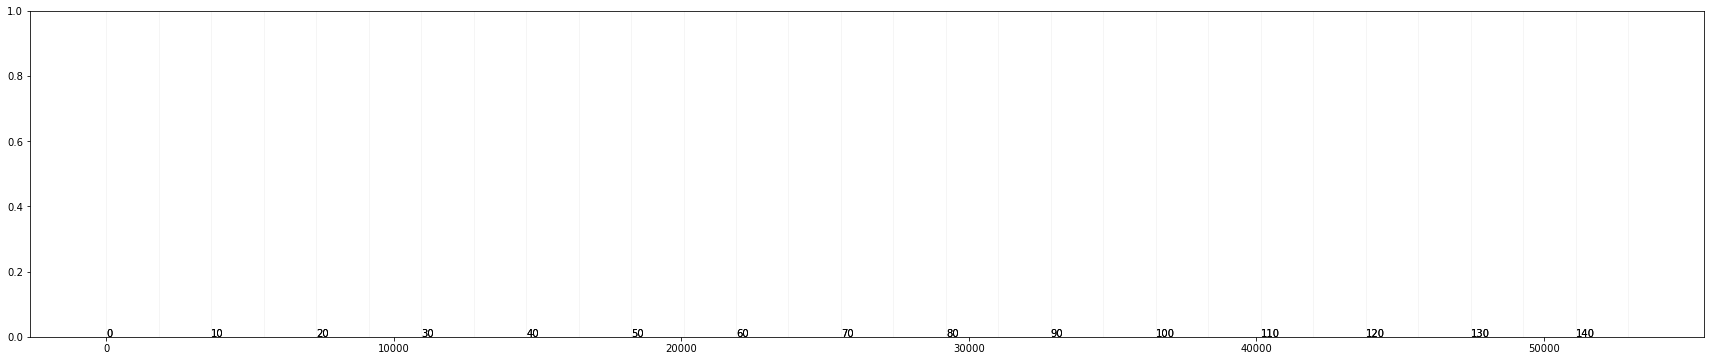

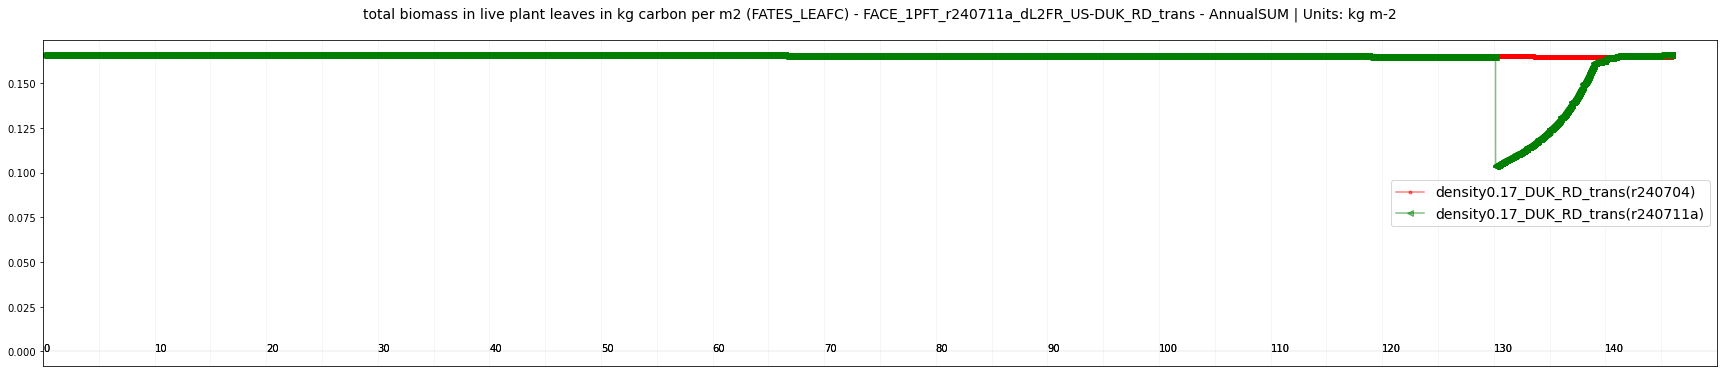

In [88]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_LEAFC",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

total biomass in live plant storage in kg carbon per m2 land area
total biomass in live plant storage in kg carbon per m2 land area


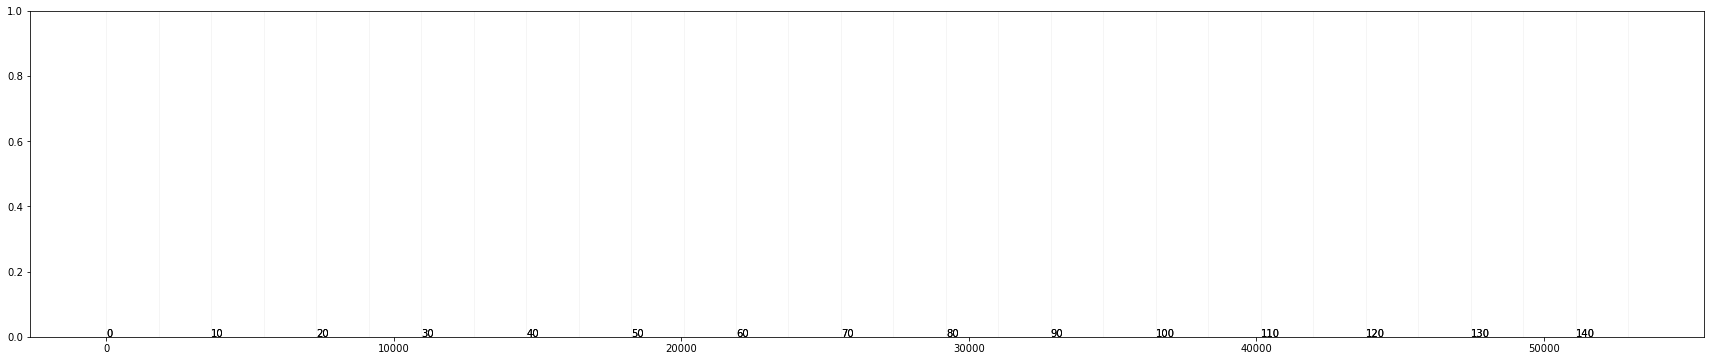

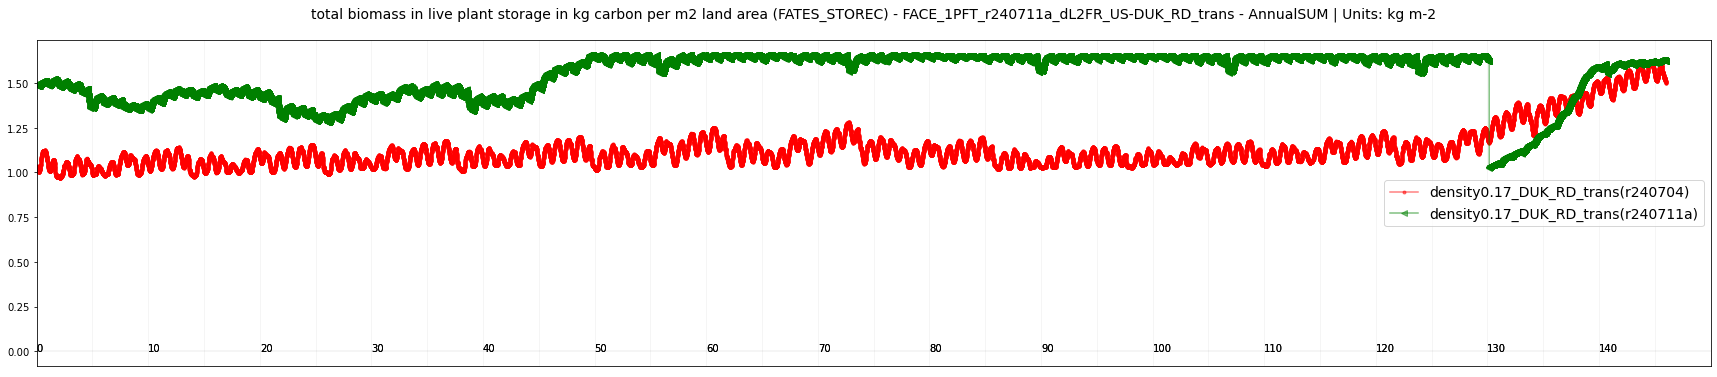

In [89]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_STOREC",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

gross primary production in kg carbon per m2 per second
gross primary production in kg carbon per m2 per second


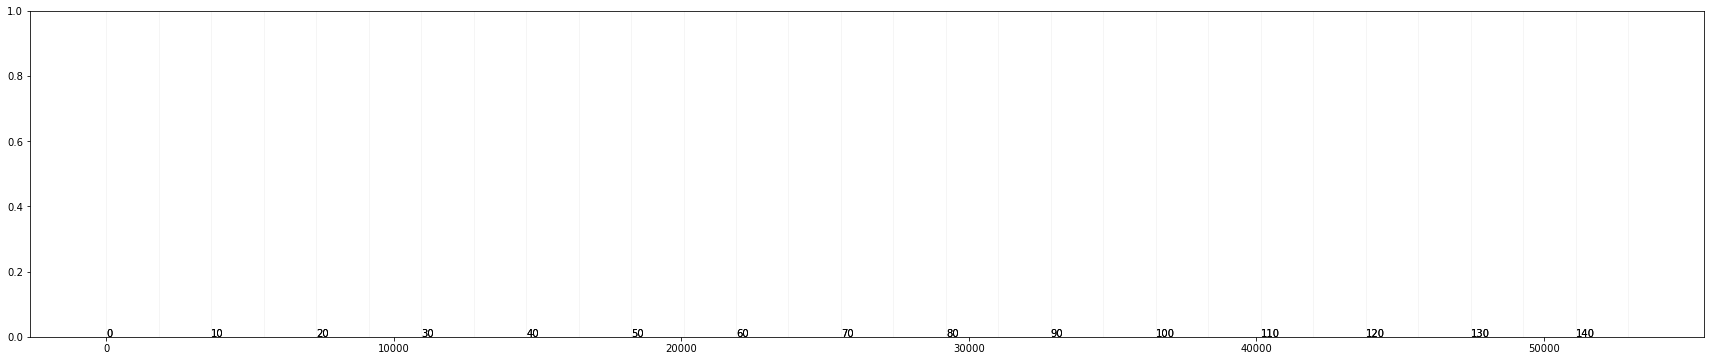

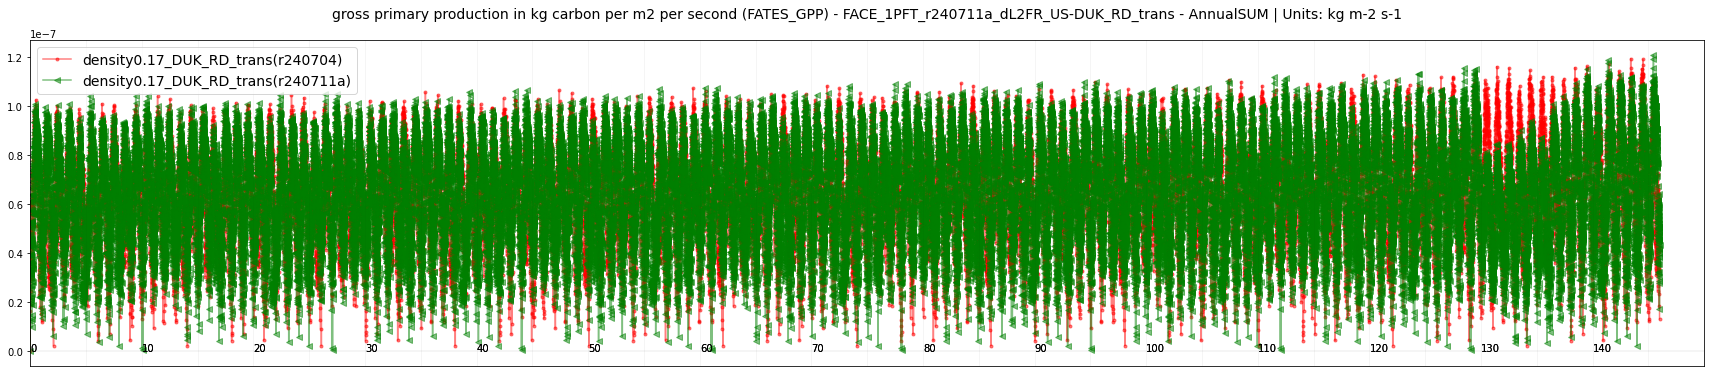

In [90]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_GPP",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

net rate of N mineralization
net rate of N mineralization


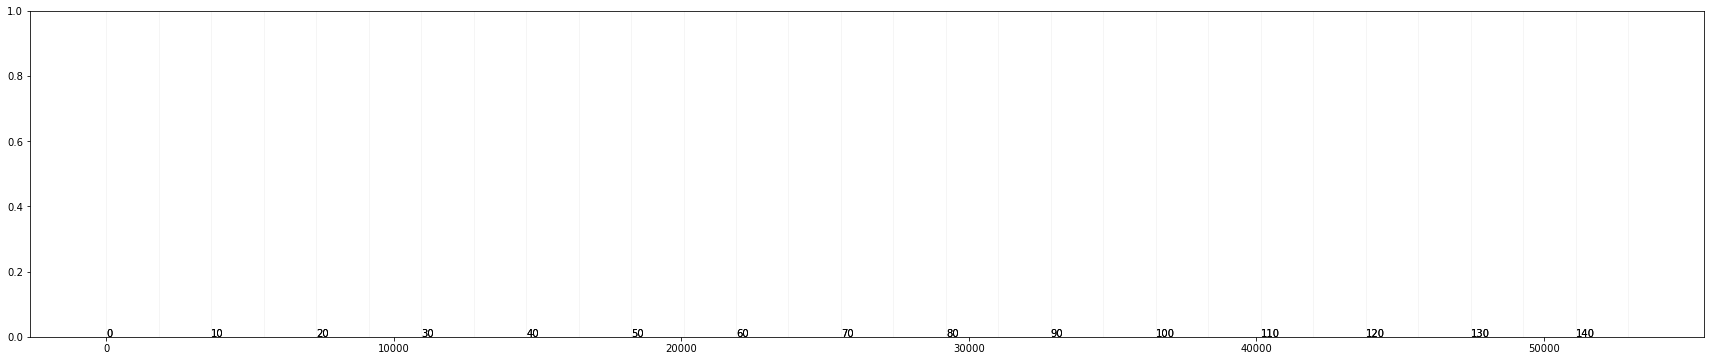

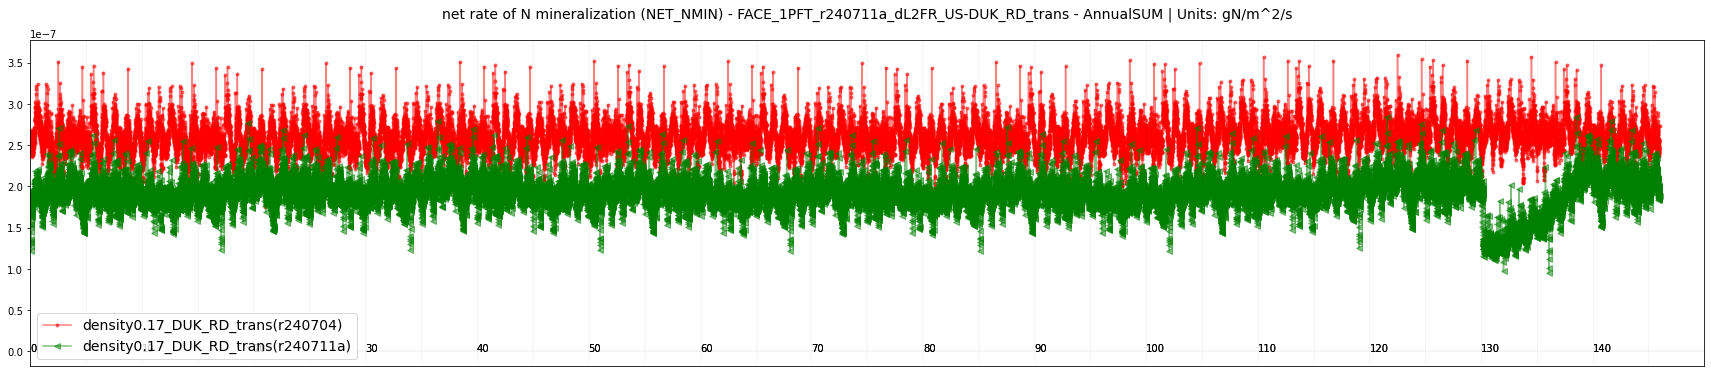

In [91]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "NET_NMIN",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

gross rate of N mineralization
gross rate of N mineralization


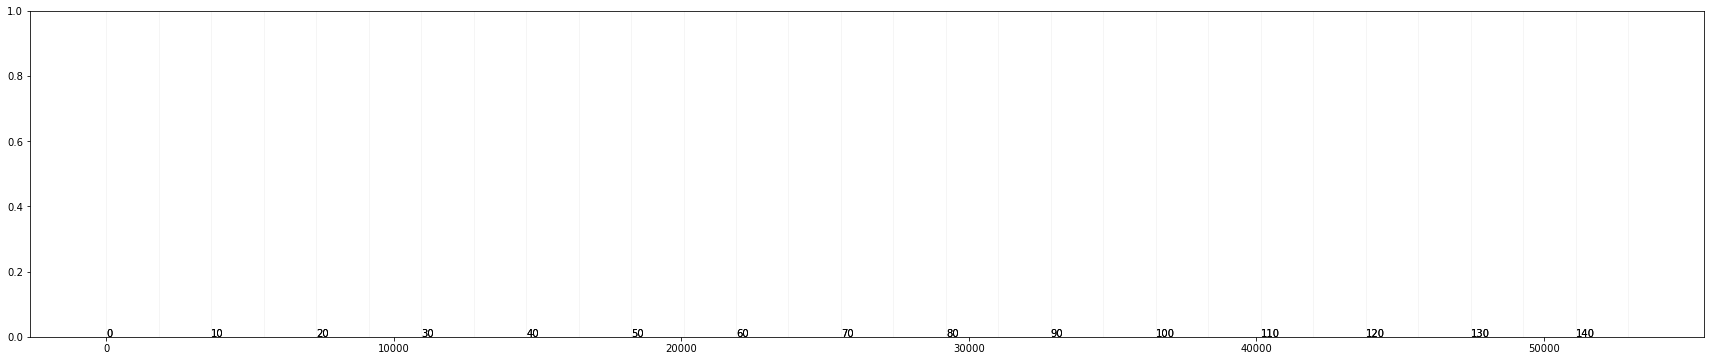

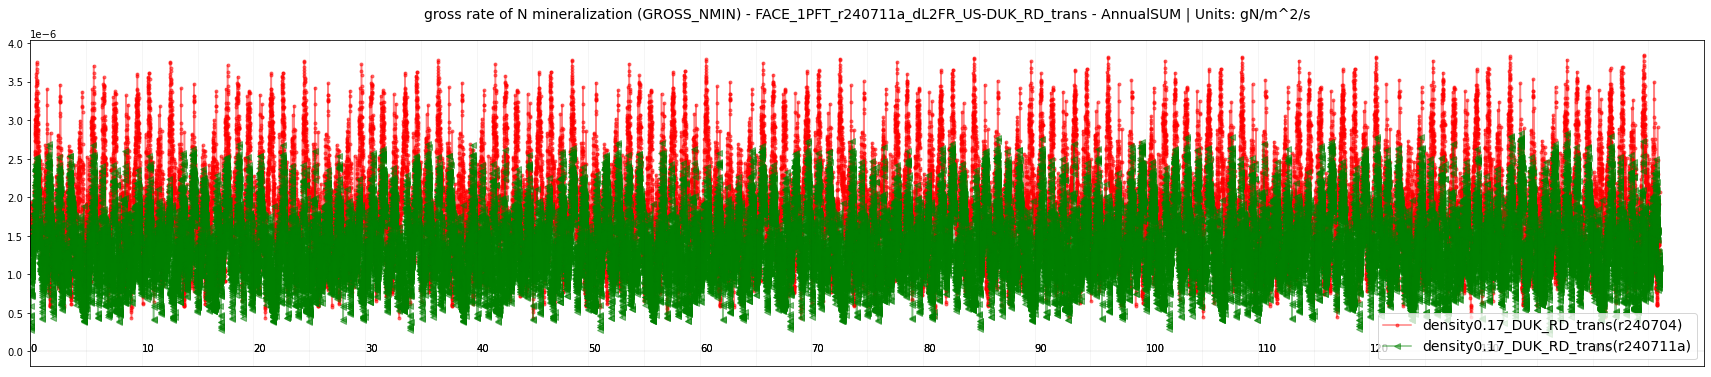

In [92]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "GROSS_NMIN",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

disturbance rate from logging
disturbance rate from logging


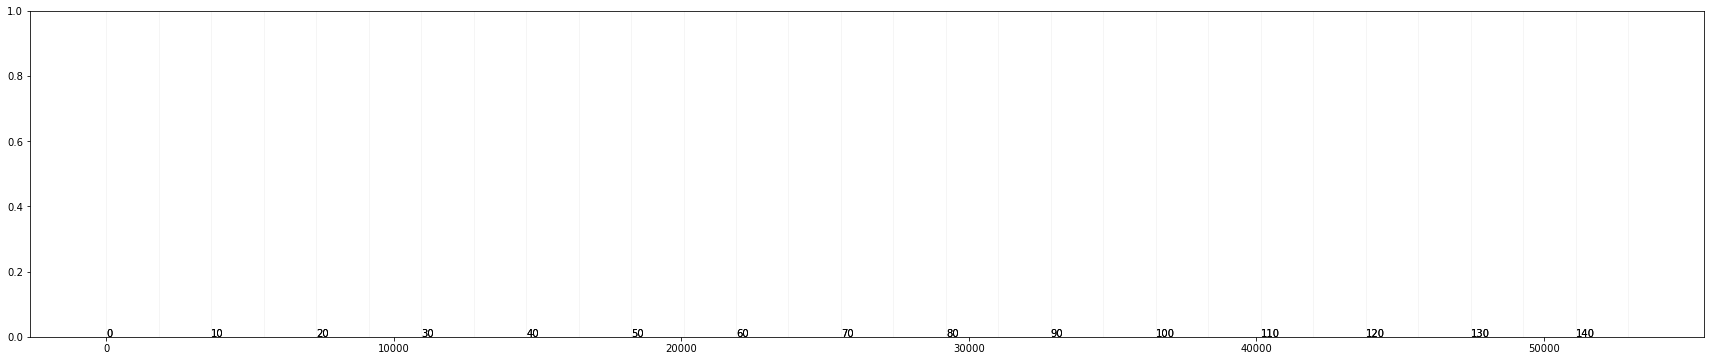

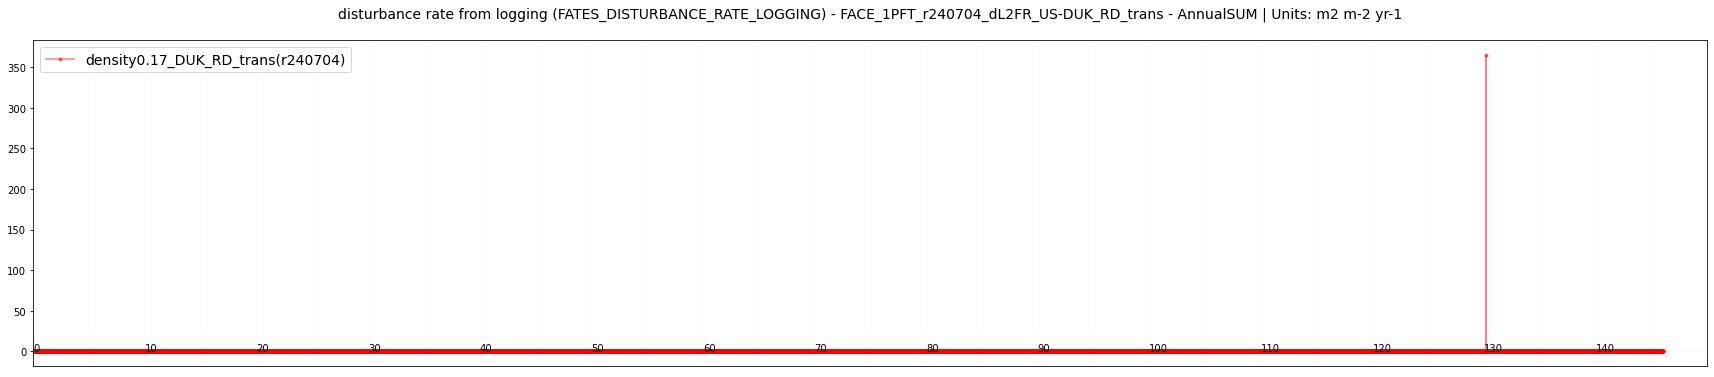

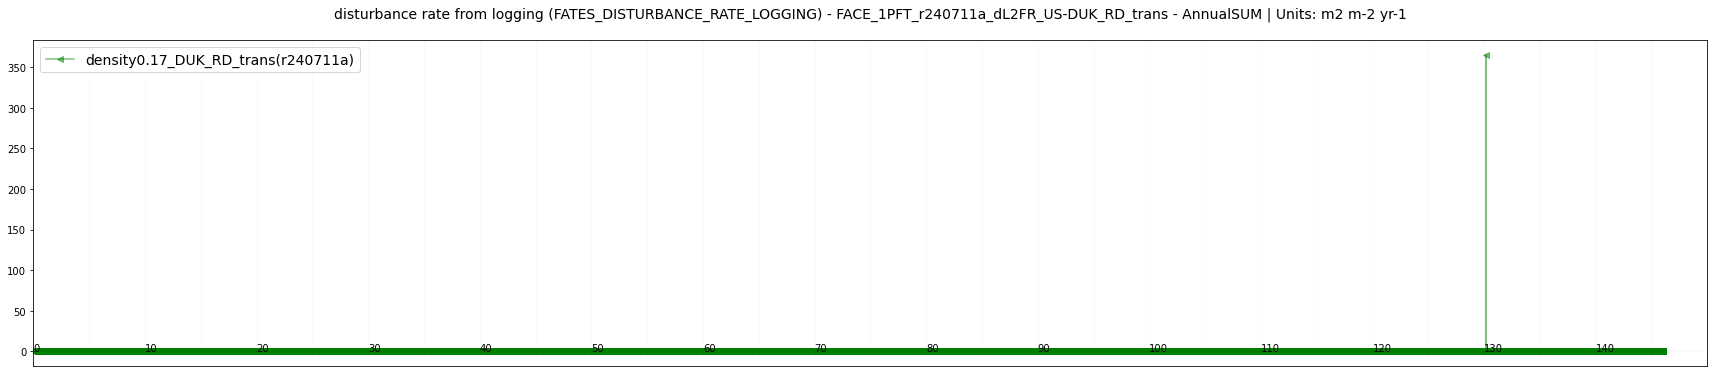

In [125]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_DISTURBANCE_RATE_LOGGING",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
#plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.figure(figsize=(30,6))
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

total biomass in live plants in kg carbon per m2 land area
total biomass in live plants in kg carbon per m2 land area


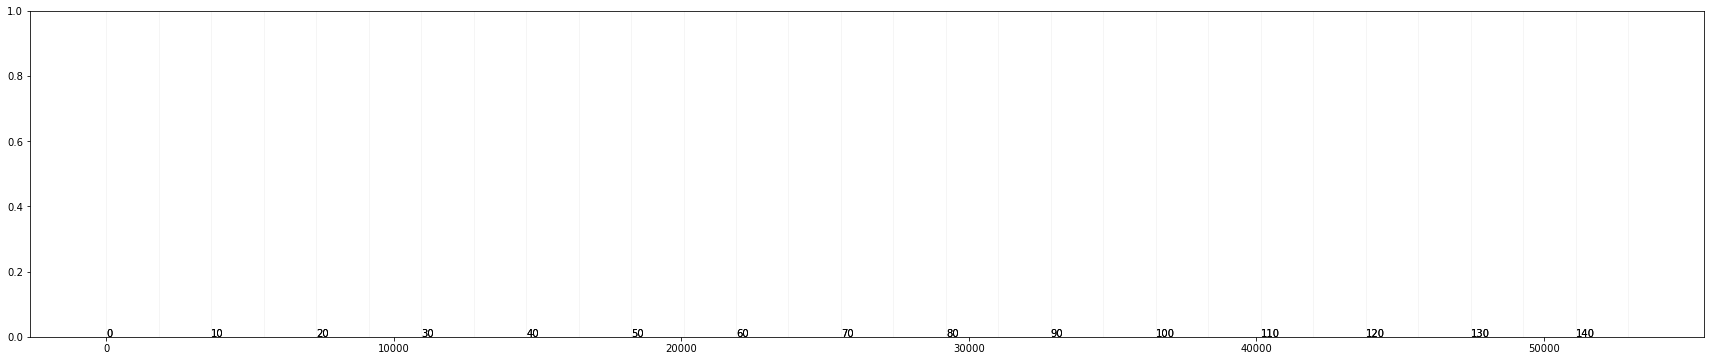

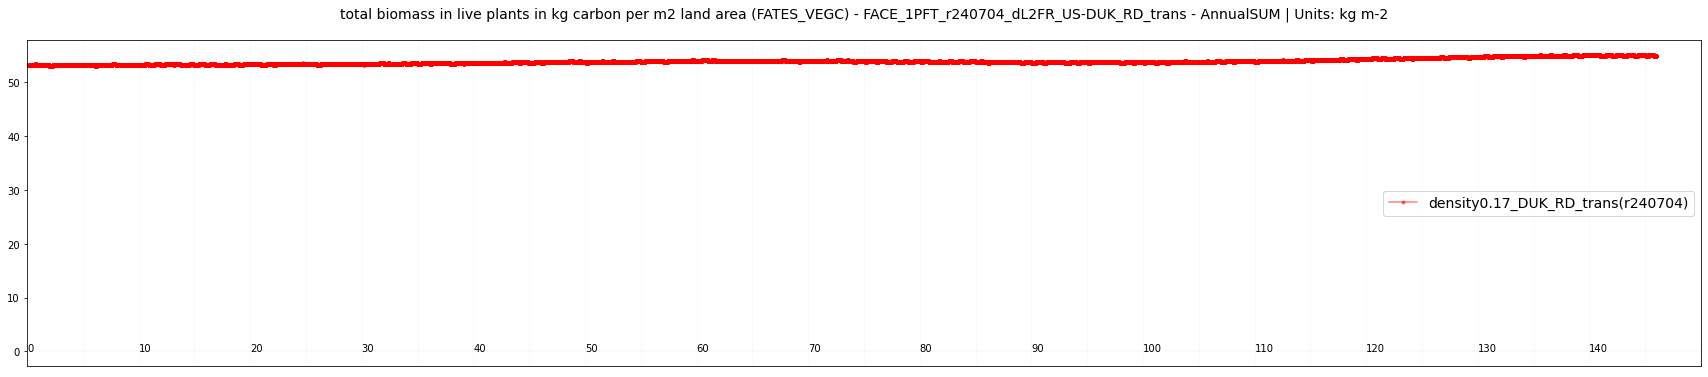

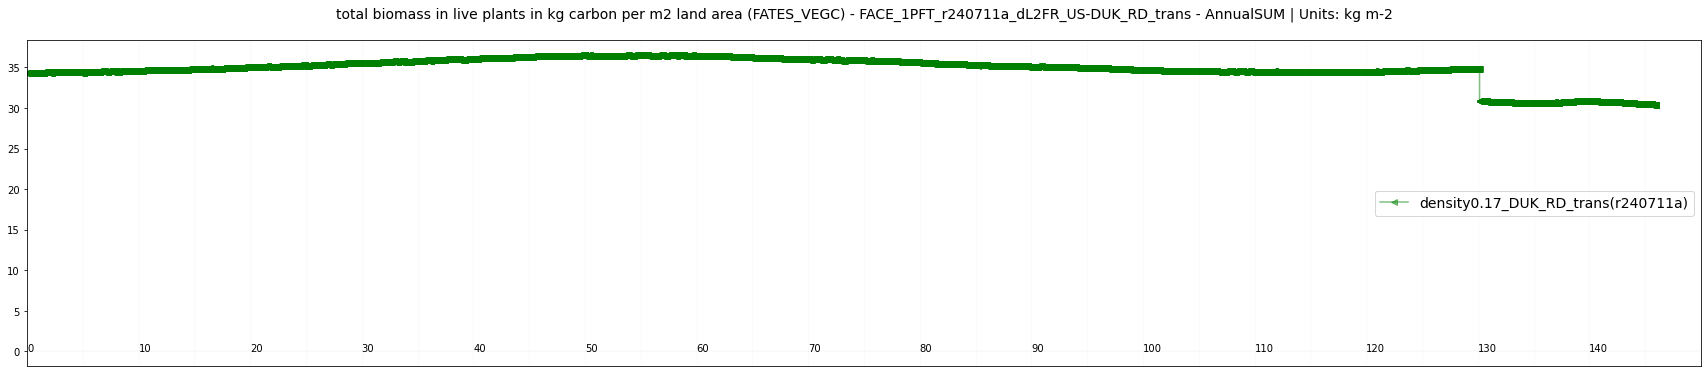

In [124]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_VEGC",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
#plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.figure(figsize=(30,6))
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

total PFT-level number of individuals per m2 land area, secondary patches
total PFT-level number of individuals per m2 land area, secondary patches


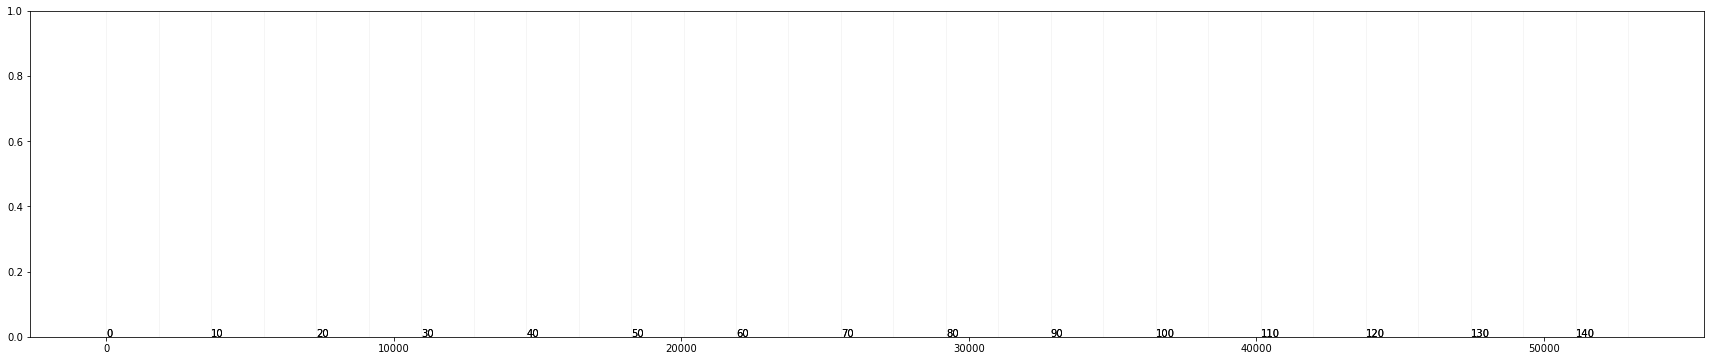

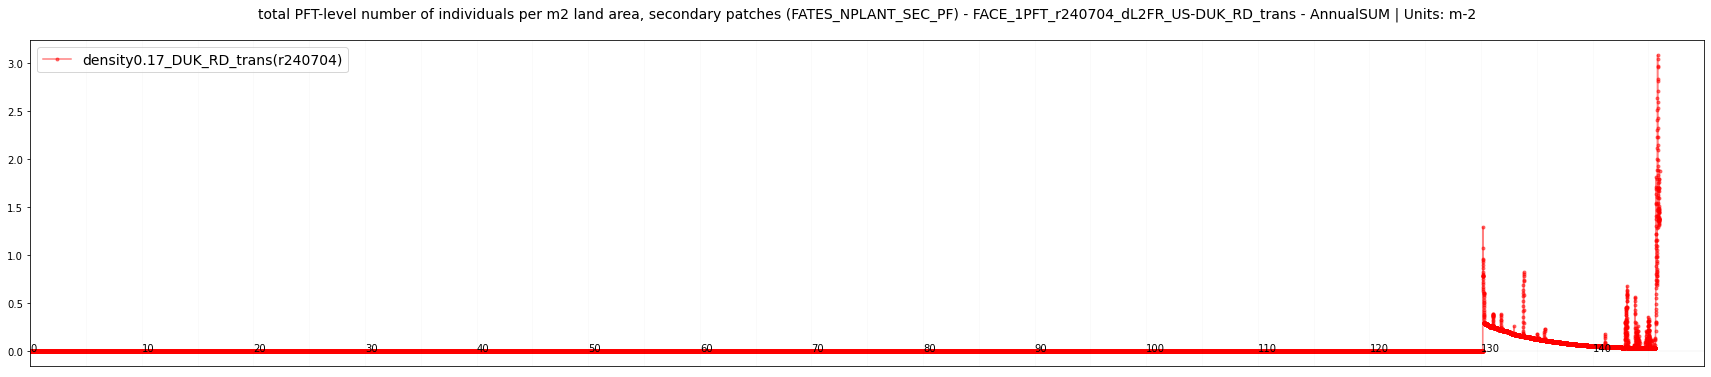

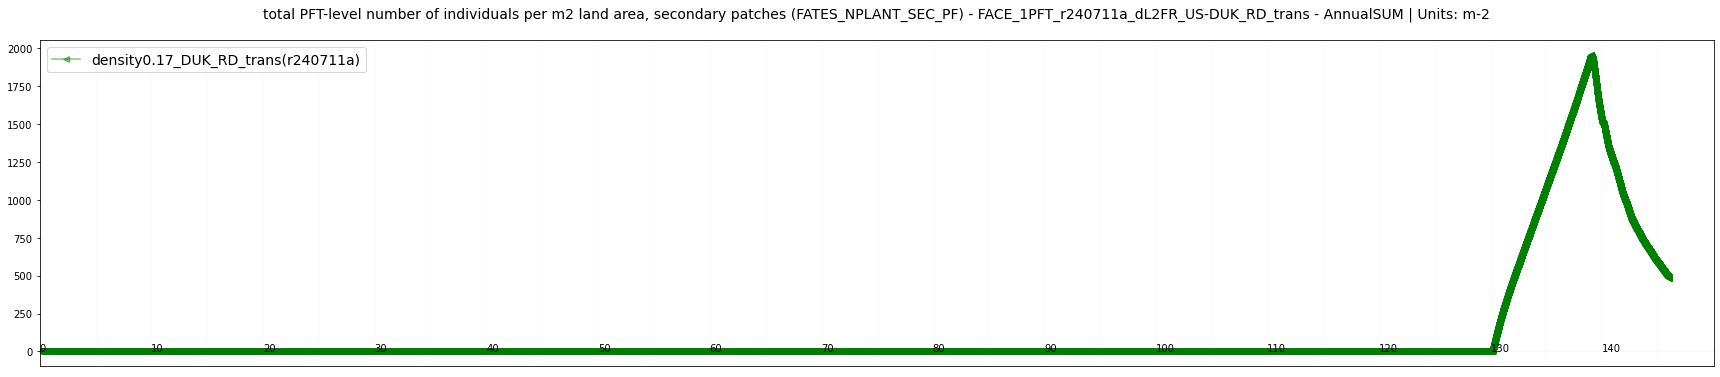

In [126]:

vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NPLANT_SEC_PF",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                ts_summed = ds[key][var].sum(dim=["fates_levpft", "lndgrid"])
                plt.plot(ts_summed, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
#plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.figure(figsize=(30,6))
                ts_summed = ds[key][var].sum(dim=["fates_levpft", "lndgrid"])
                plt.plot(ts_summed, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

total PFT-level number of individuals per m2 land area
total PFT-level number of individuals per m2 land area


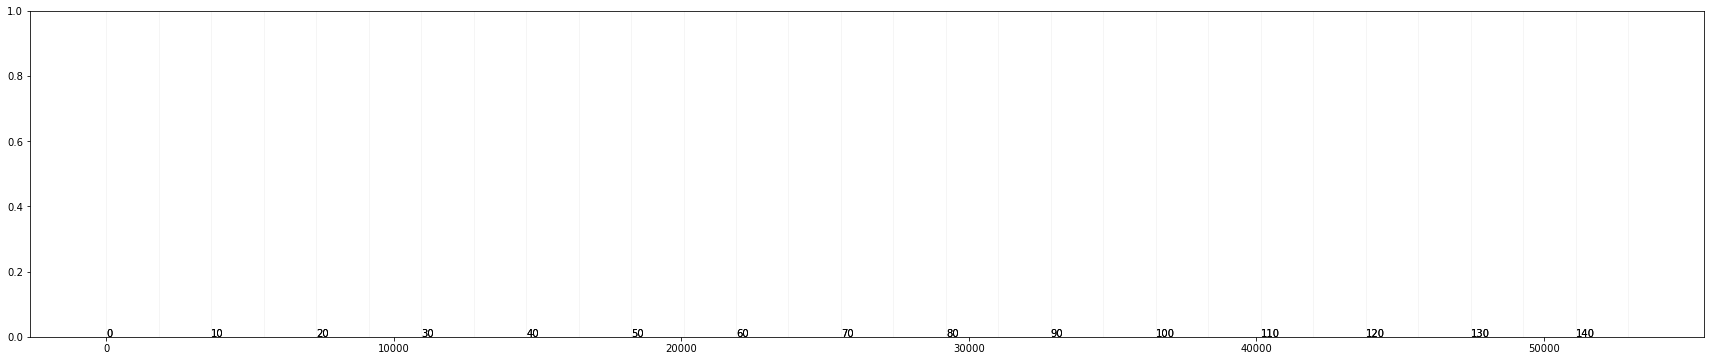

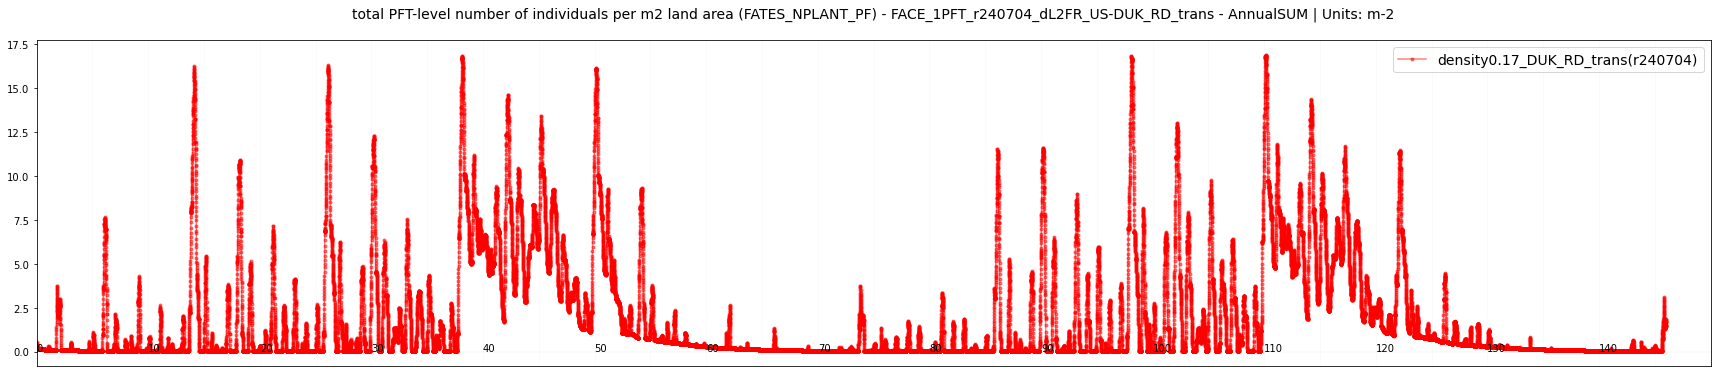

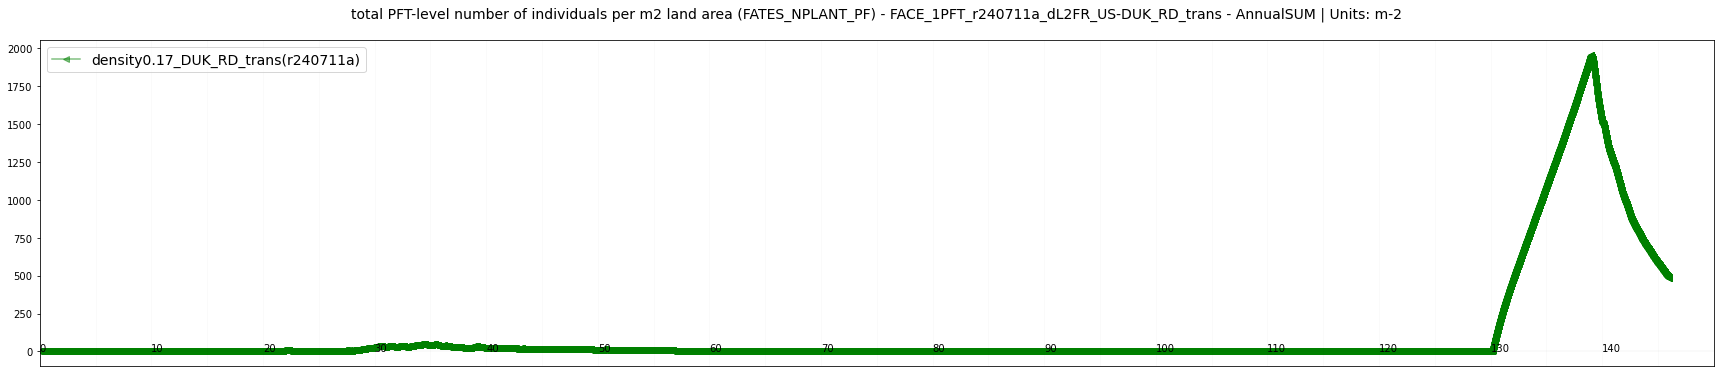

In [122]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NPLANT_PF",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                ts_summed = ds[key][var].sum(dim=["fates_levpft", "lndgrid"])
                plt.plot(ts_summed, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
#plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.figure(figsize=(30,6))
                ts_summed = ds[key][var].sum(dim=["fates_levpft", "lndgrid"])
                plt.plot(ts_summed, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

number of plants per m2 by cohort age class
number of plants per m2 by cohort age class


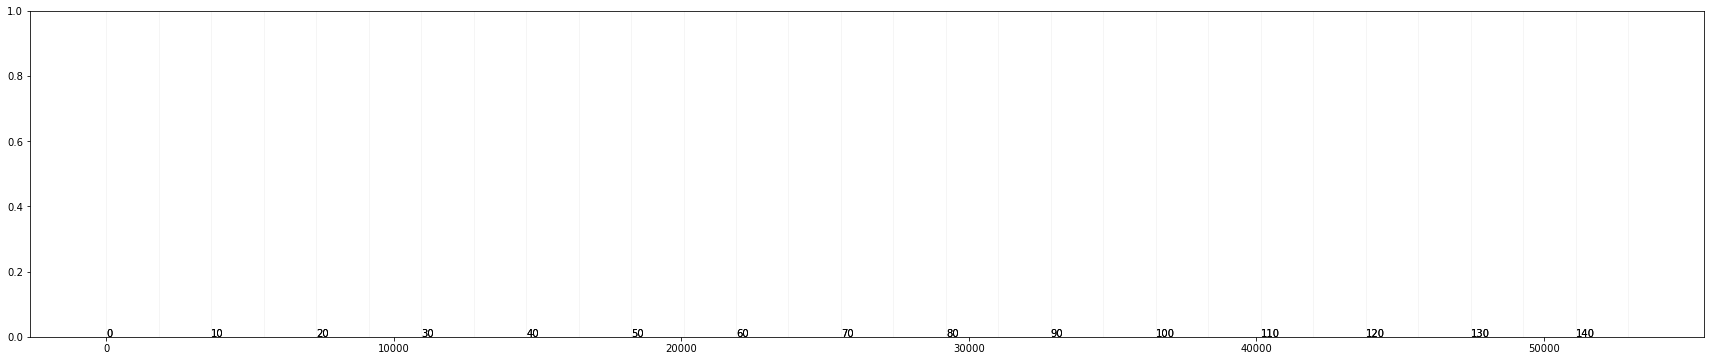

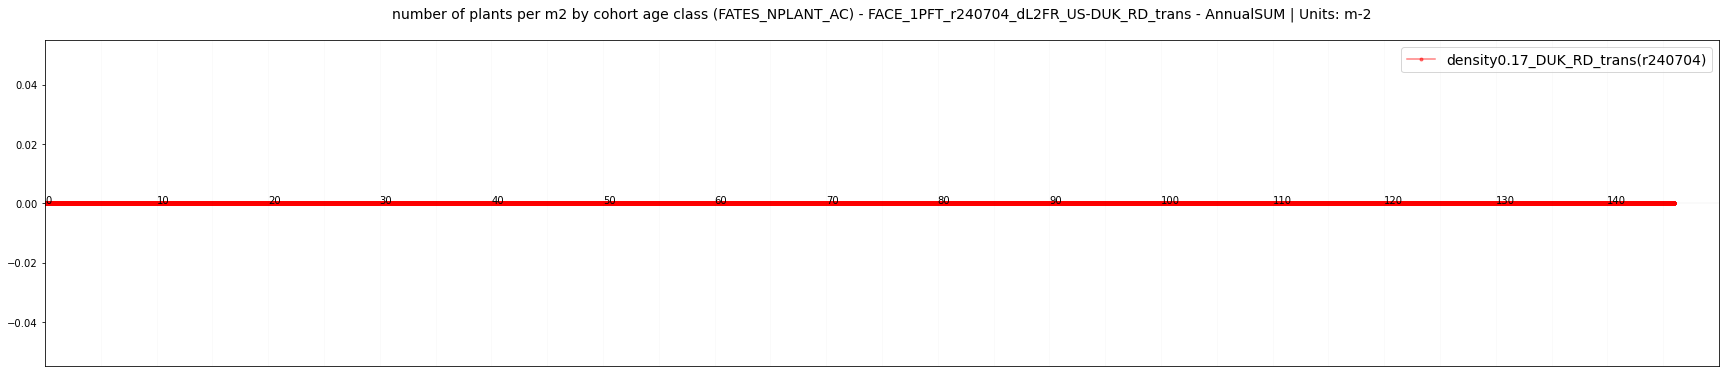

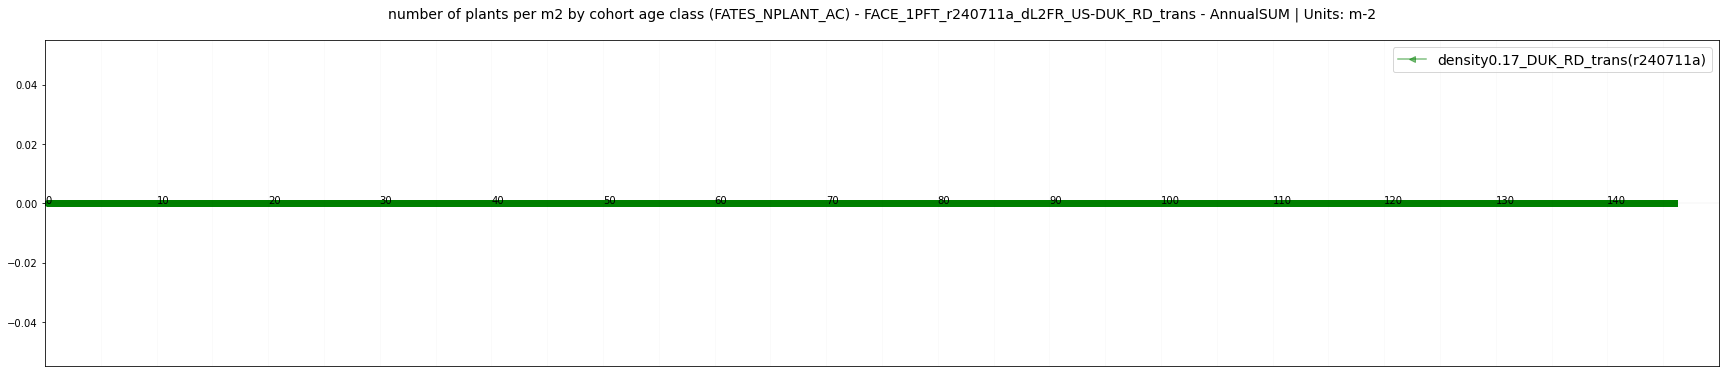

In [118]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NPLANT_AC",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                ts_summed = ds[key][var].sum(dim=["fates_levcacls", "lndgrid"])
                plt.plot(ts_summed, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
#plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.figure(figsize=(30,6))
                ts_summed = ds[key][var].sum(dim=["fates_levcacls", "lndgrid"])
                plt.plot(ts_summed, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

number of plants per m2 by size class
number of plants per m2 by size class


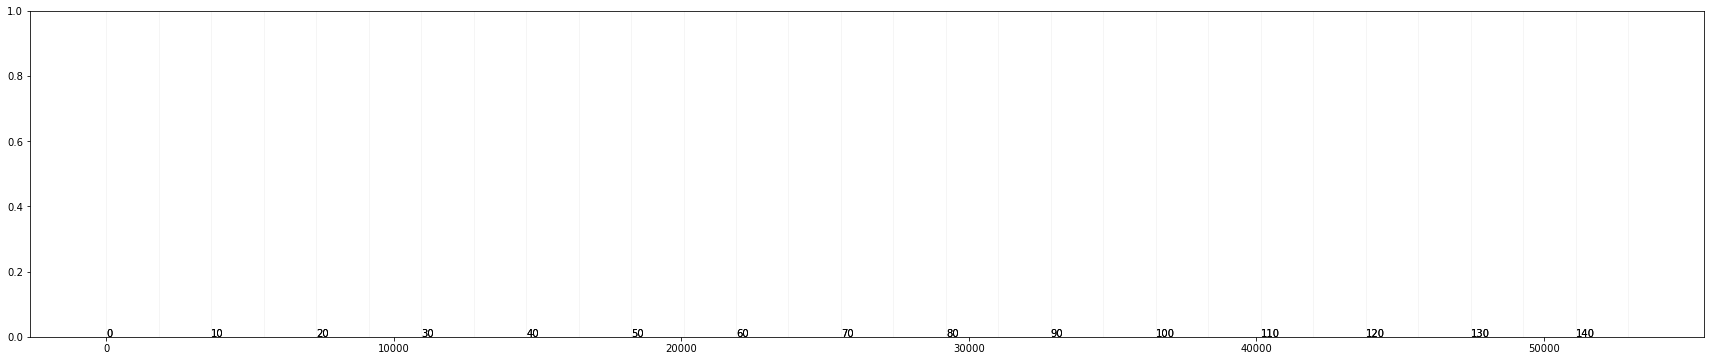

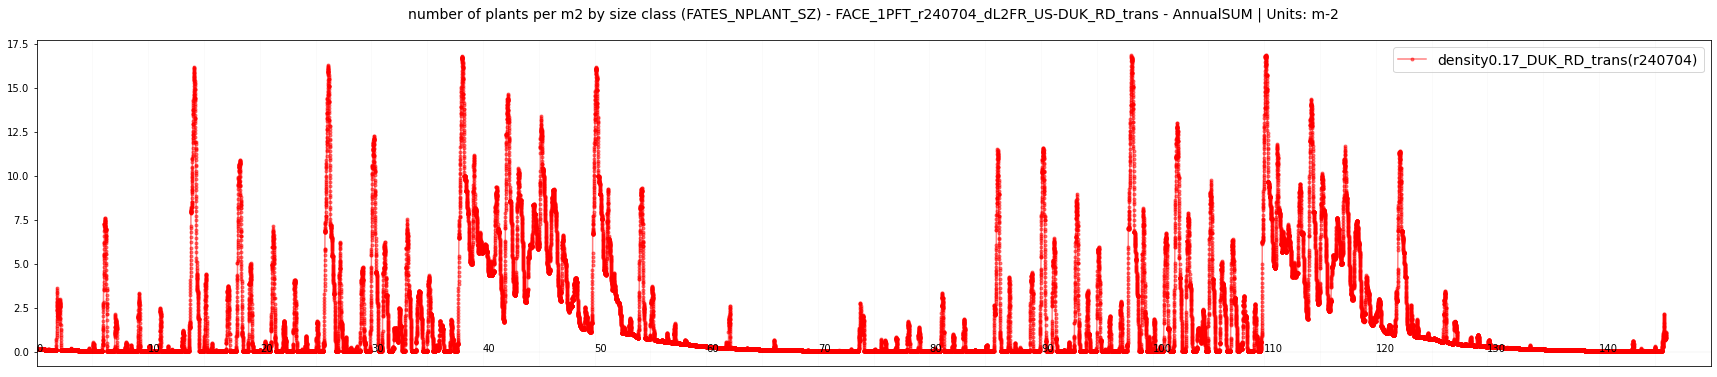

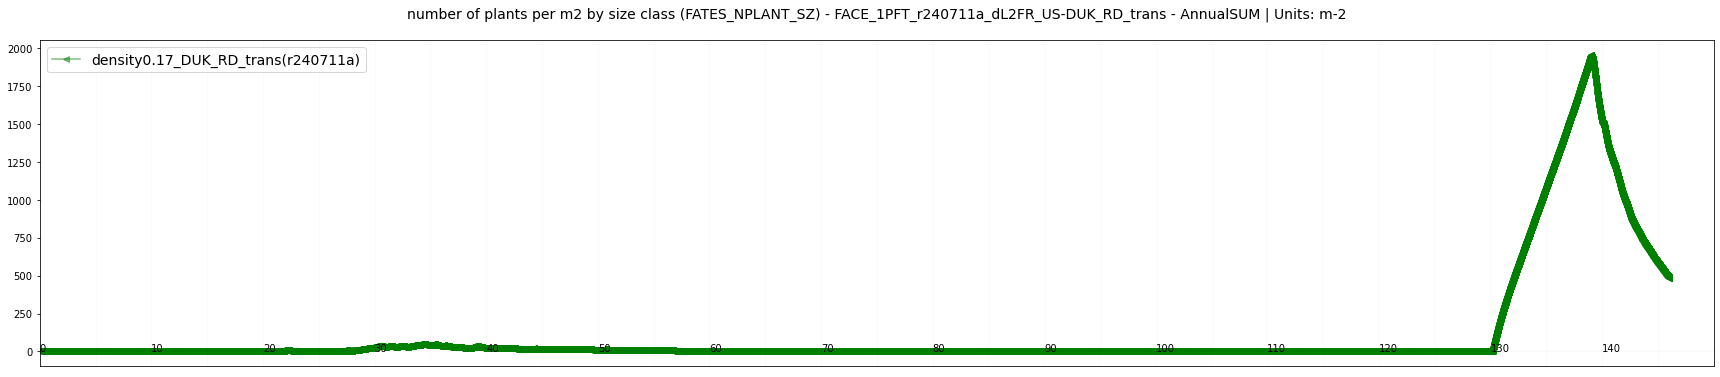

In [128]:

vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NPLANT_SZ",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                ts_summed = ds[key][var].sum(dim=["fates_levscls", "lndgrid"])
                plt.plot(ts_summed, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
#plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.figure(figsize=(30,6))
                ts_summed = ds[key][var].sum(dim=["fates_levscls", "lndgrid"])
                plt.plot(ts_summed, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

diameter growth increment by size of canopy plants
diameter growth increment by size of canopy plants


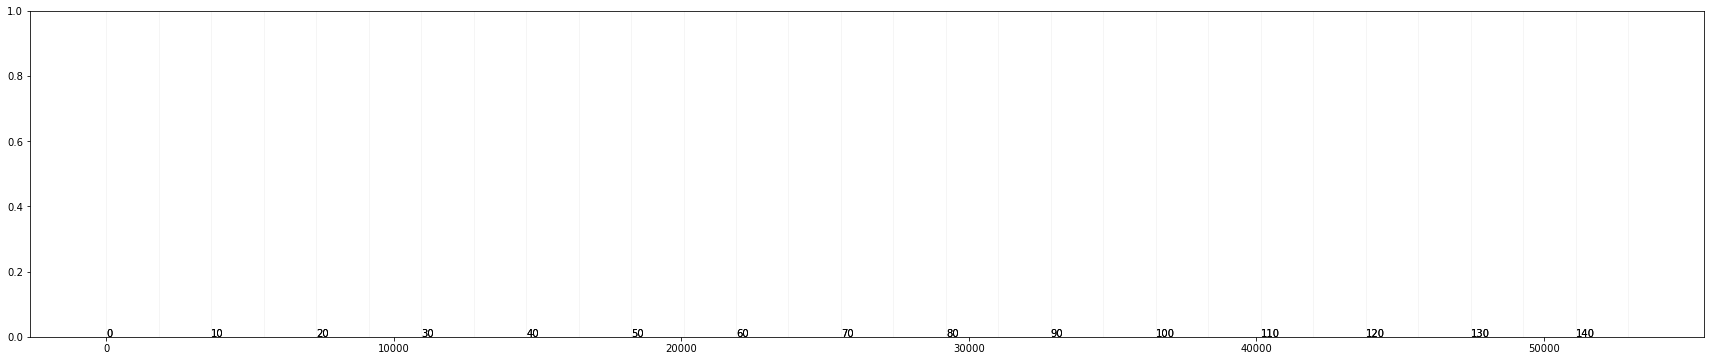

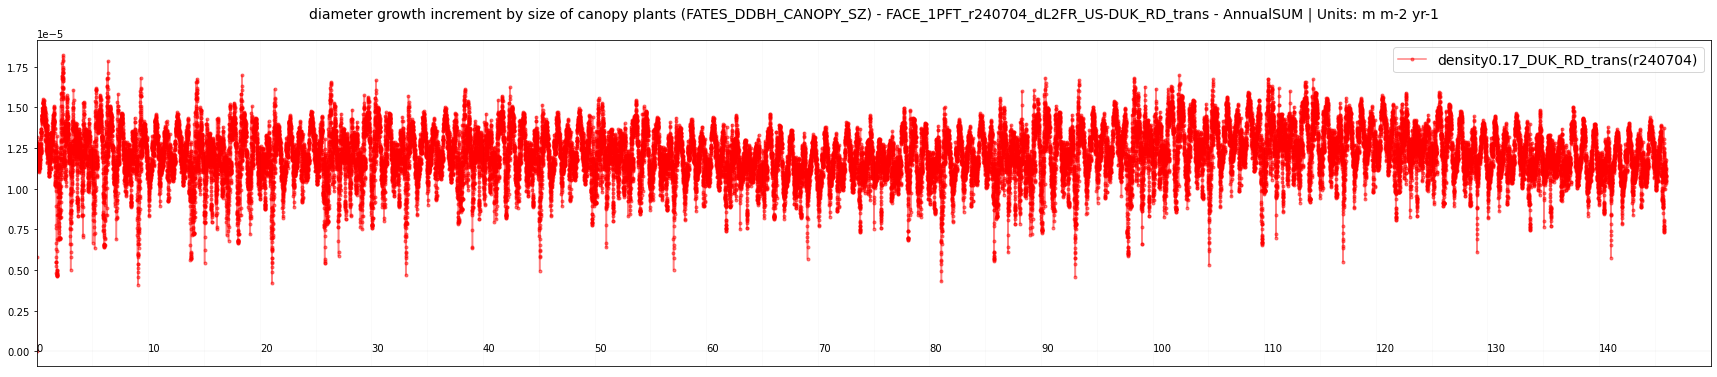

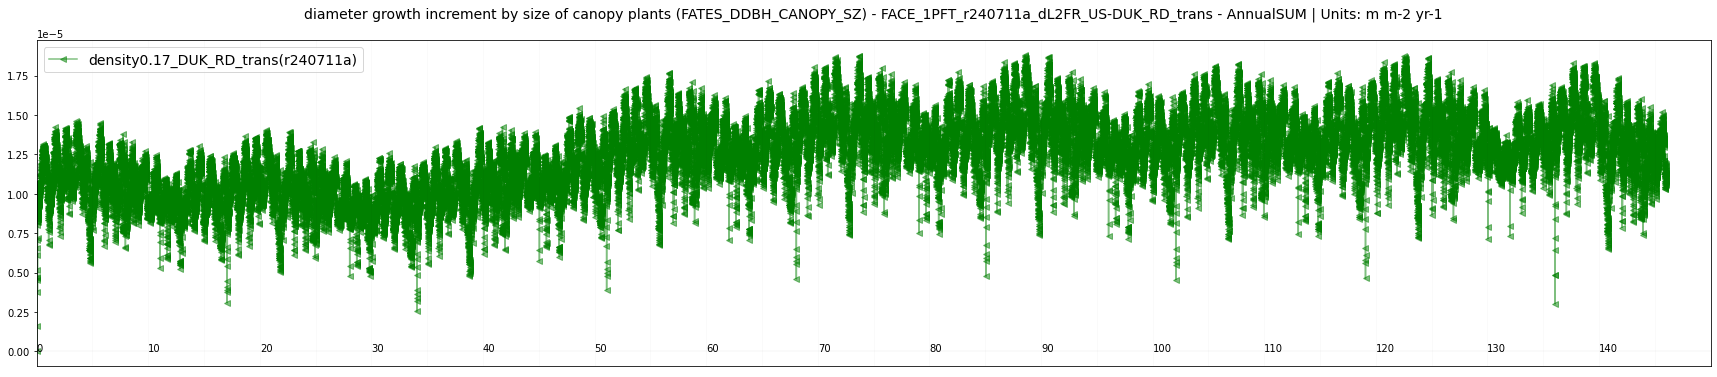

In [115]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_DDBH_CANOPY_SZ",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                ts_summed = ds[key][var].sum(dim=["fates_levscls", "lndgrid"])
                plt.plot(ts_summed, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
#plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.figure(figsize=(30,6))
                # Sum across all dimensions except for 'time'
                ts_summed = ds[key][var].sum(dim=["fates_levscls", "lndgrid"])
                plt.plot(ts_summed, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

diameter growth increment by size of understory plants
diameter growth increment by size of understory plants


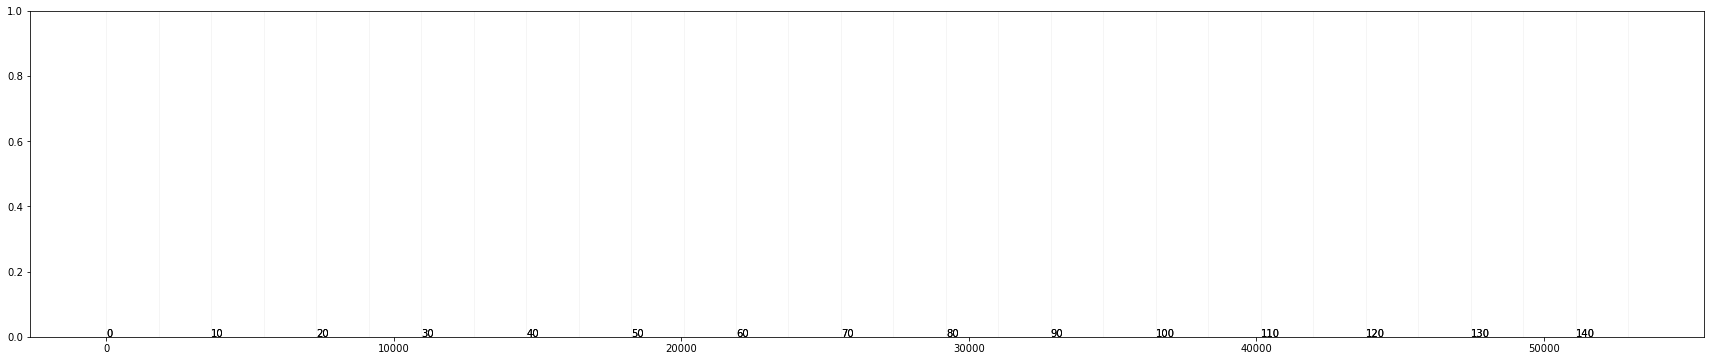

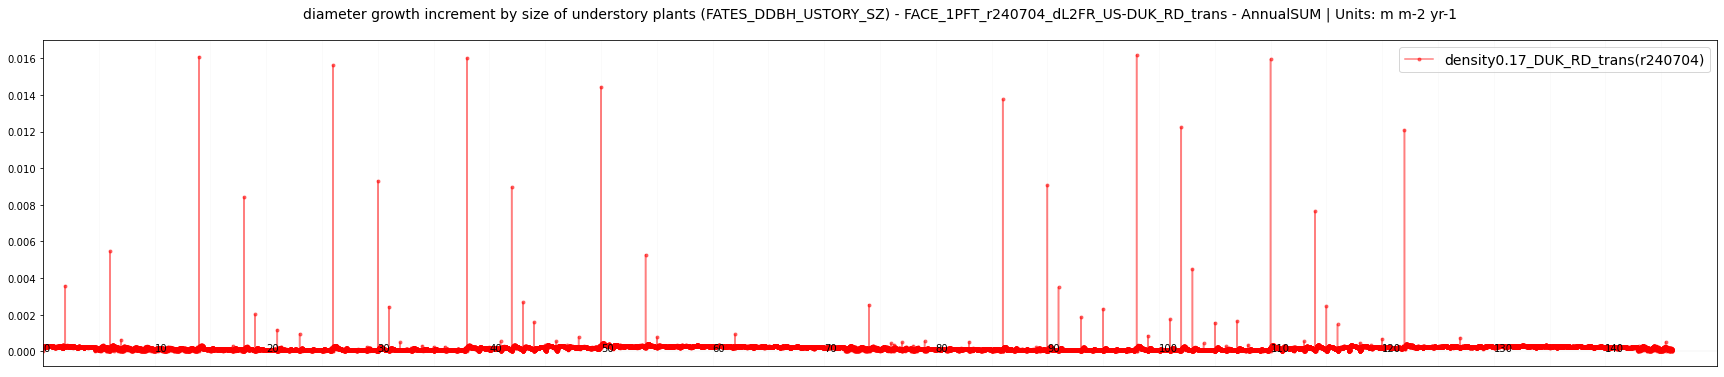

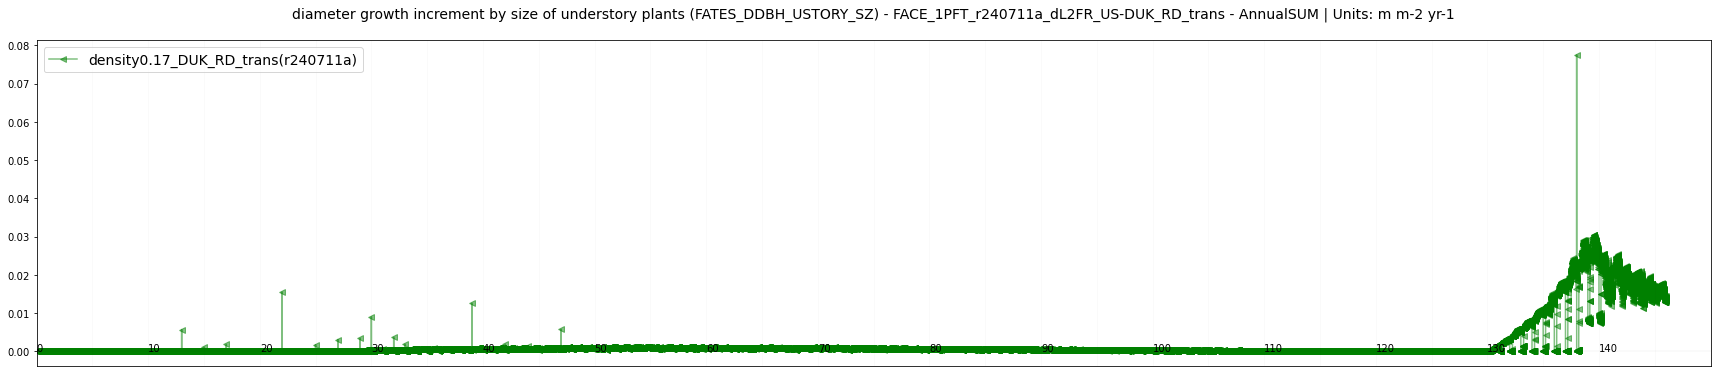

In [116]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_DDBH_USTORY_SZ",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                ts_summed = ds[key][var].sum(dim=["fates_levscls", "lndgrid"])
                plt.plot(ts_summed, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
#plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.figure(figsize=(30,6))
                # Sum across all dimensions except for 'time'
                ts_summed = ds[key][var].sum(dim=["fates_levscls", "lndgrid"])
                plt.plot(ts_summed, color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

In [112]:
ds[key][var]

<xarray.DataArray 'FATES_DDBH_CANOPY_SZ' (time: 53290, fates_levscls: 13, lndgrid: 1)>
dask.array<open_dataset-9ecff7217ca433c8572029d9c48e48e3FATES_DDBH_CANOPY_SZ, shape=(53290, 13, 1), dtype=float32, chunksize=(53290, 13, 1), chunktype=numpy.ndarray>
Coordinates:
  * time           (time) float64 0.0 1.0 2.0 ... 5.329e+04 5.329e+04 5.329e+04
  * fates_levscls  (fates_levscls) float64 0.0 5.0 10.0 15.0 ... 80.0 90.0 100.0
Dimensions without coordinates: lndgrid
Attributes:
    units:      m m-2 yr-1
    long_name:  diameter growth increment by size of canopy plants

total number of patches per site
total number of patches per site


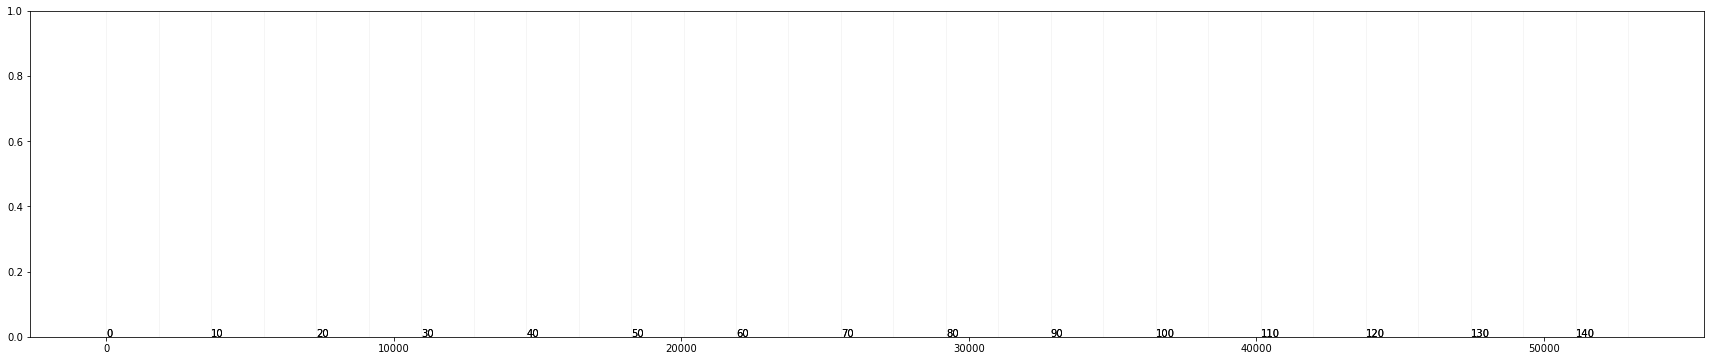

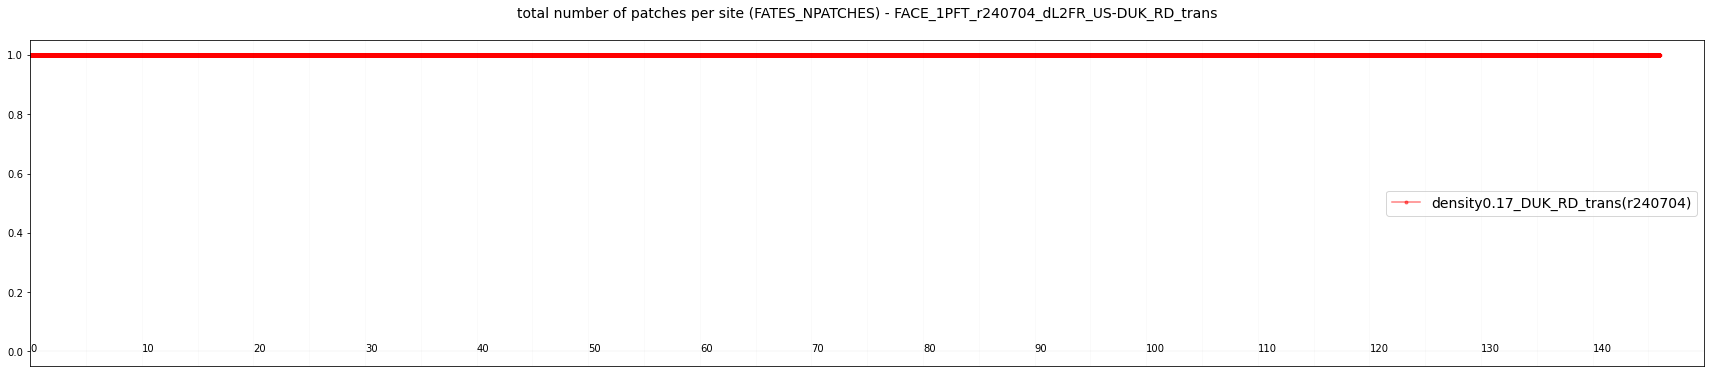

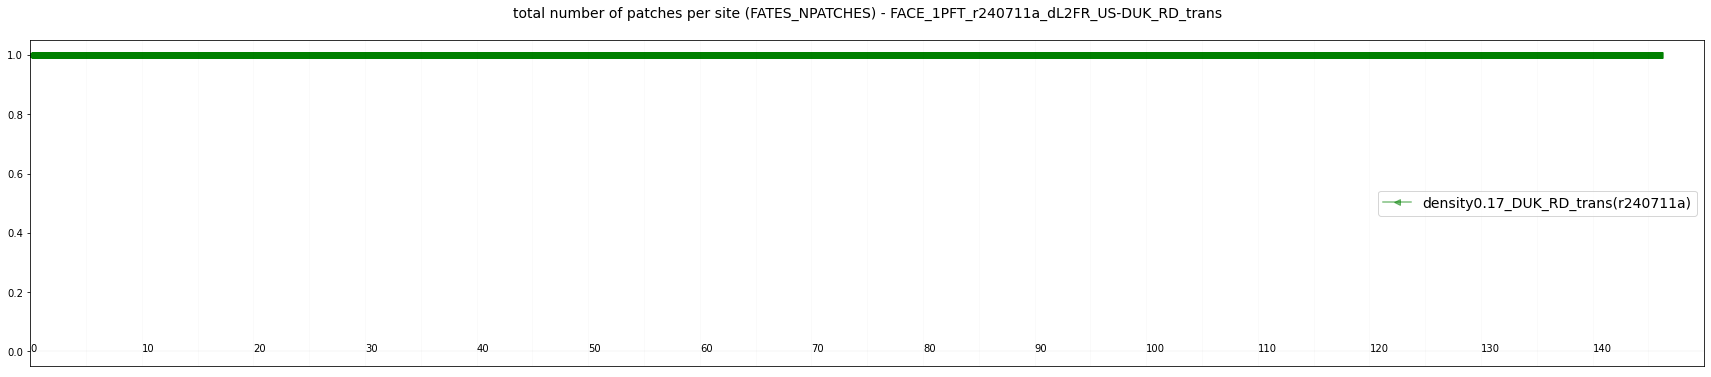

In [133]:
# NOunits
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NPATCHES",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} \n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index

for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key: 
                plt.figure(figsize=(30,6))
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

total number of patches per site
total number of patches per site


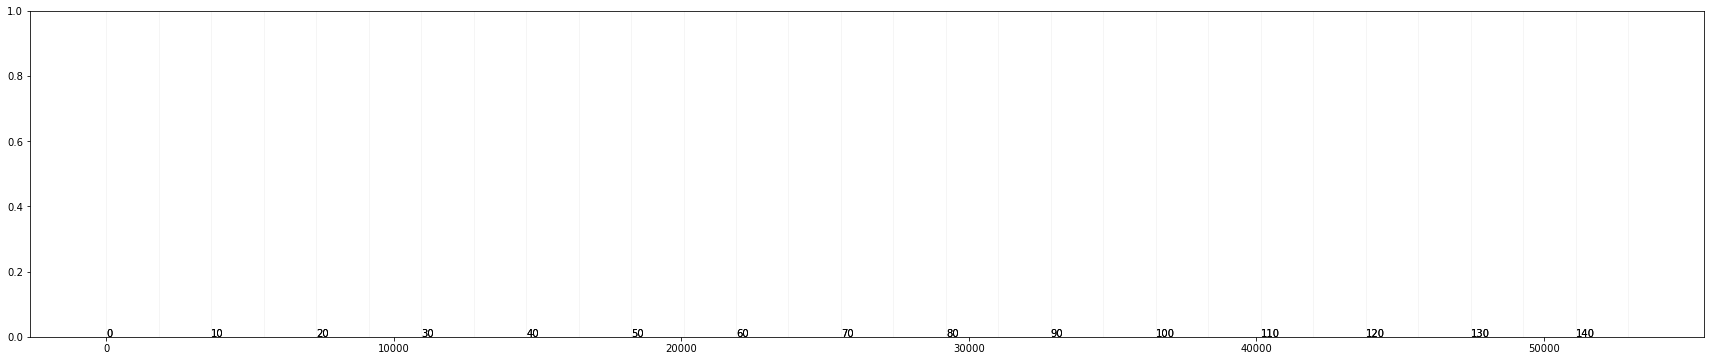

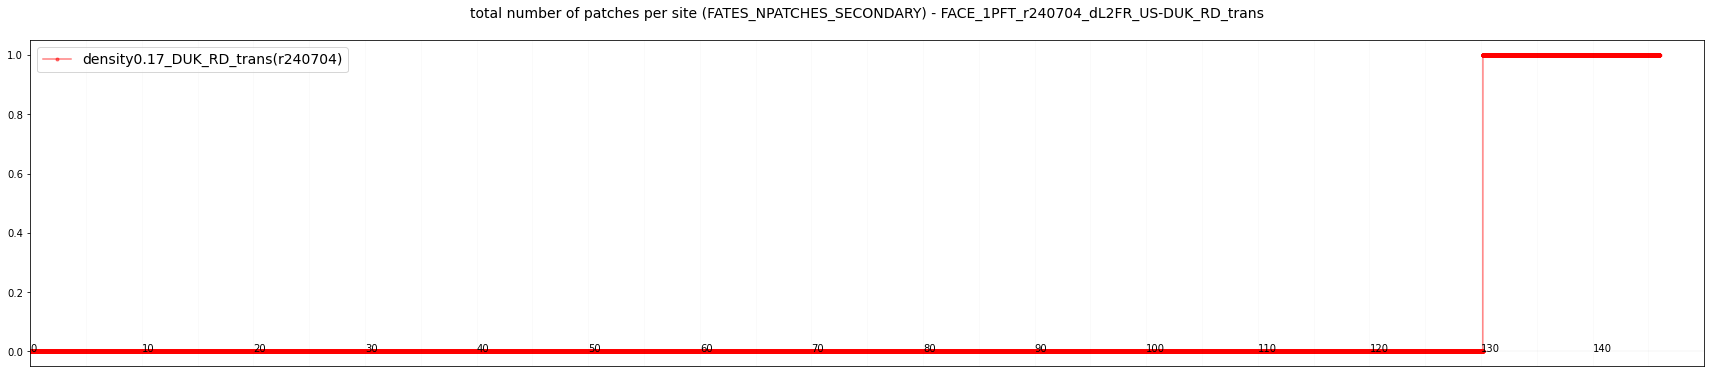

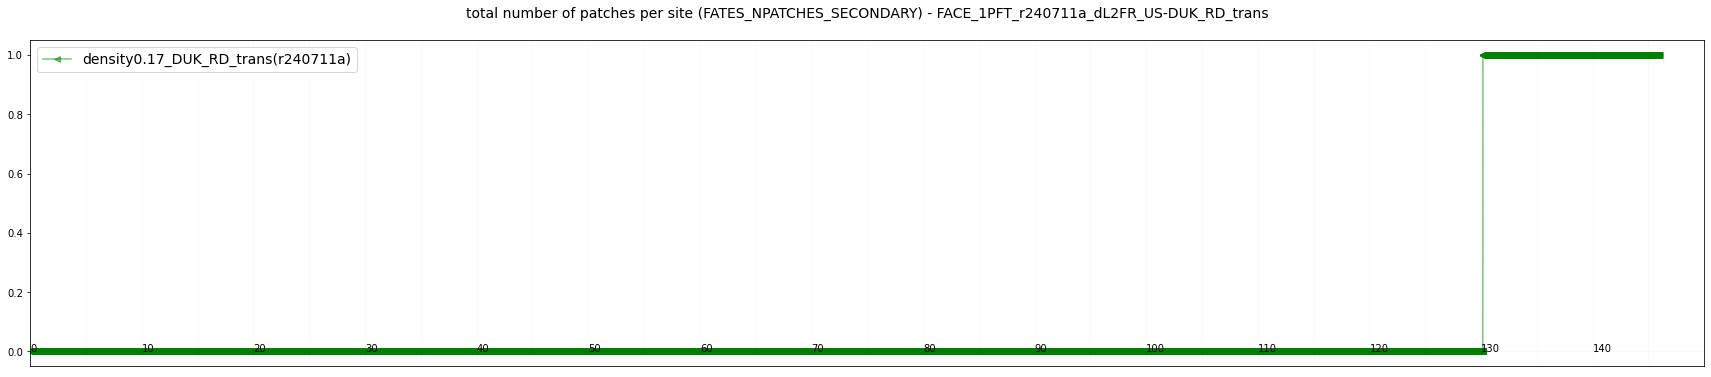

In [132]:
# NOunits
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NPATCHES_SECONDARY",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} \n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index

for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:  
                plt.figure(figsize=(30,6))
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

soil mineral N
soil mineral N


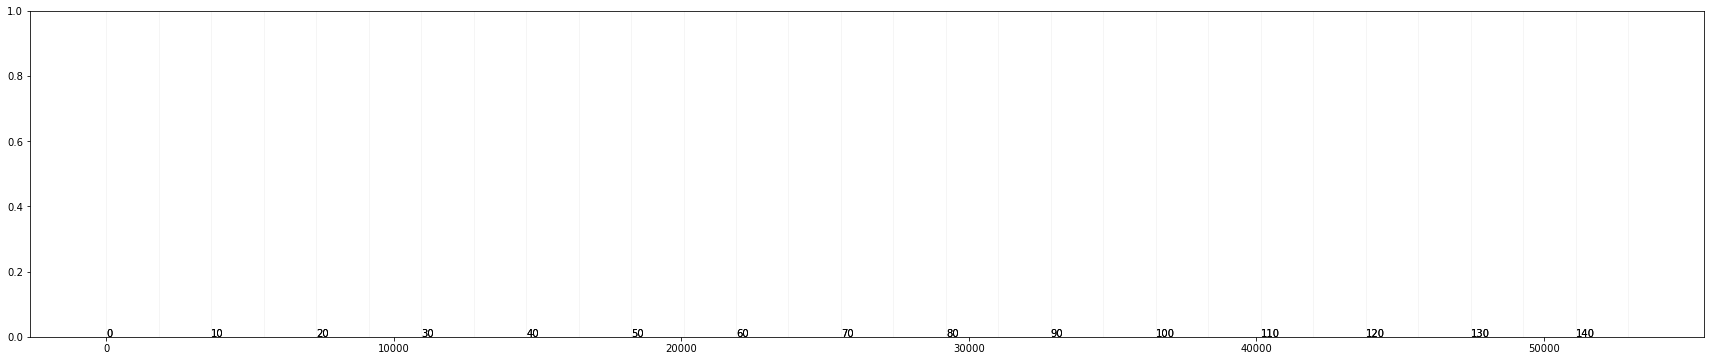

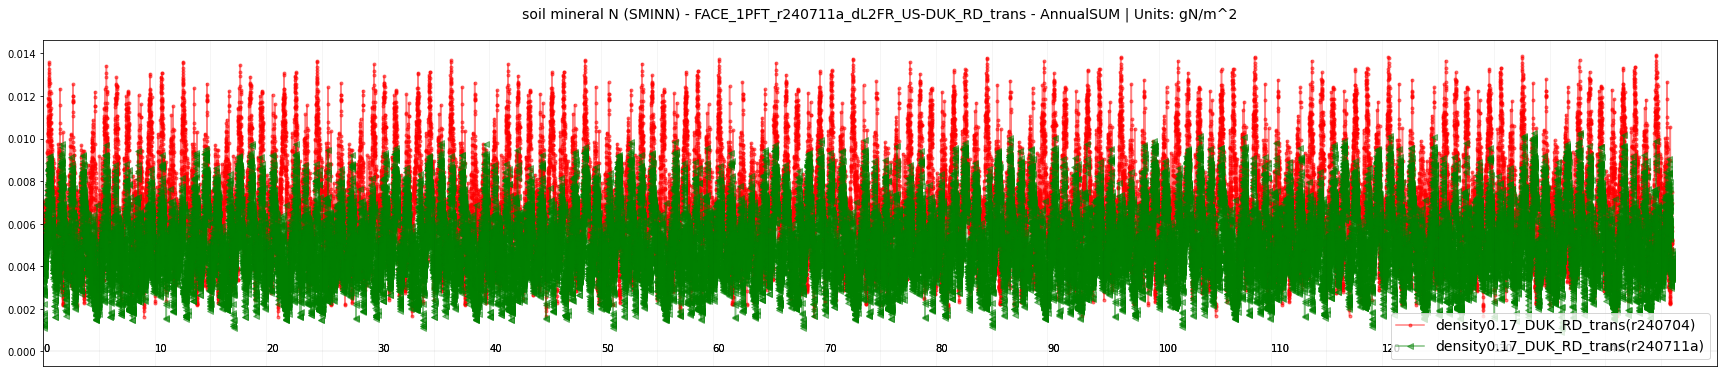

In [93]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "SMINN",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

## focussing on logging event

net primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second


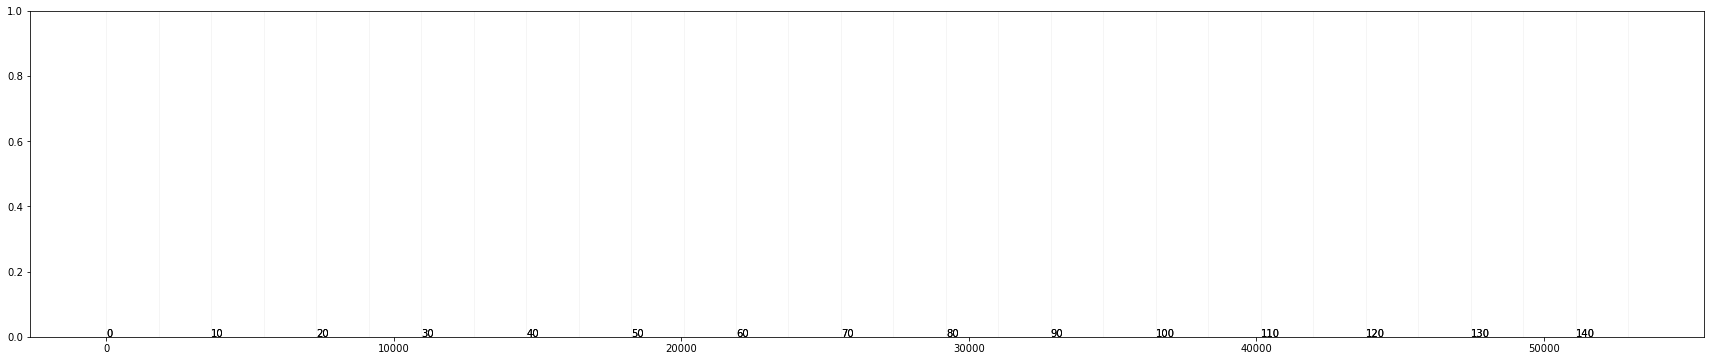

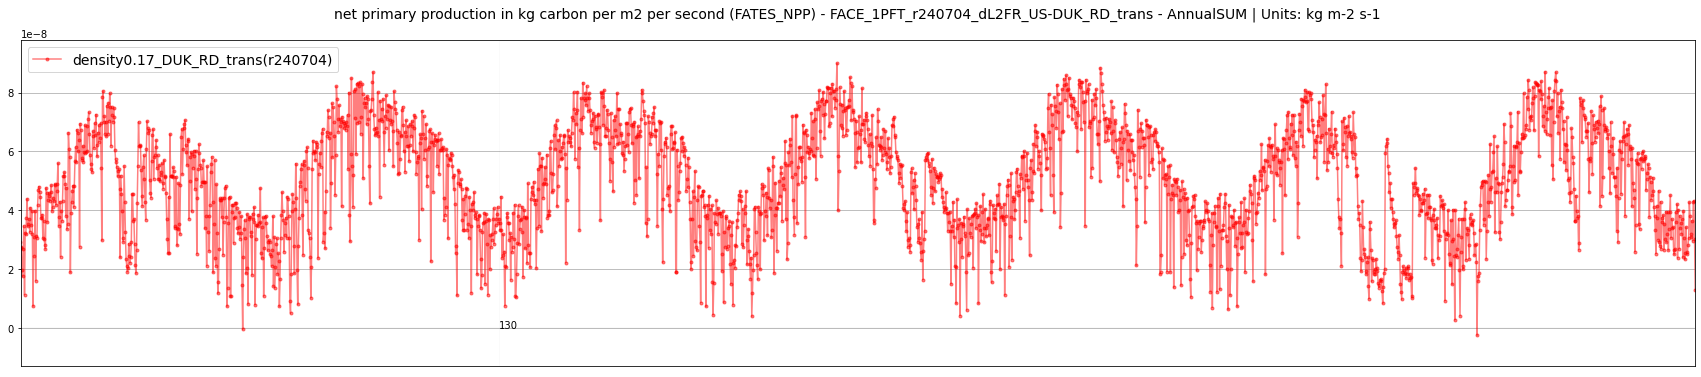

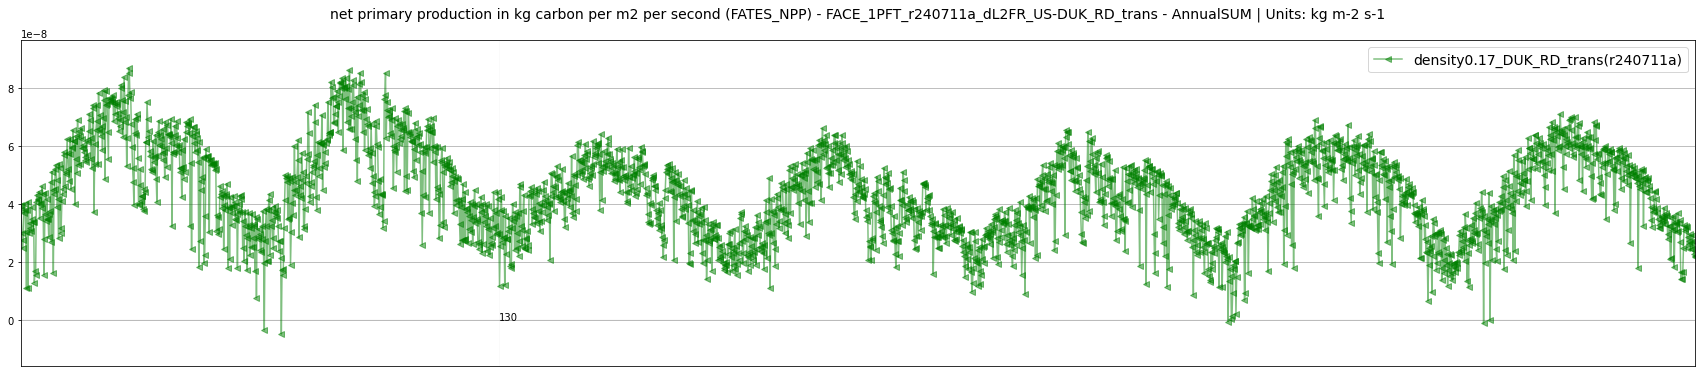

In [153]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NPP",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n",fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index

min_years = 128
max_years = 135
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:  
                plt.figure(figsize=(30,6))
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n", fontsize=14)
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend(fontsize=14)
                plt.xlim(min_years*multiply_factor,max_years*multiply_factor)
                li+=1 # for legend index updating for a site
                plt.grid()
        for i in range(min_years, max_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

In [136]:
ds[key][var].shape

(53290, 1)

In [63]:
key

'FACE_1PFT_r240711a_dL2FR_US-DUK_ECA_eCO2'

In [68]:
k = "FACE_1PFT_r240711a_dL2FR_US-DUK_RD_trans"

In [69]:
ds[k][var].plot()

KeyError: 'FACE_1PFT_r240711a_dL2FR_US-DUK_RD_trans'

duke logging 1980-03-01
Index should be : (1980-1850 +1) x365 = 47815 

In [66]:
ii = 47450-365*10
var = "FATES_DISTURBANCE_RATE_LOGGING"
#ds[k][var][ii:ii+365*10].plot()
ds[k][var].plot()

KeyError: 'FACE_1PFT_r240711a_dL2FR_US-DUK_RD_trans'

In [67]:
k = "FACE_1PFT_r240704_dL2FR_US-DUK_RD_trans"
var = "FATES_DISTURBANCE_RATE_LOGGING"

ds[k][var].plot()

KeyError: 'FACE_1PFT_r240704_dL2FR_US-DUK_RD_trans'

In [ ]:
k = "FACE_1PFT_r2407011a_dL2FR_US-DUK_RD_trans"
var = "FATES_DISTURBANCE_RATE_LOGGING"

ds[k][var].plot()